Trial 1 loaded. Proto shape: (10, 128)
Trial 2 loaded. Proto shape: (10, 128)
Trial 3 loaded. Proto shape: (10, 128)
Trial 4 loaded. Proto shape: (10, 128)
Trial 5 loaded. Proto shape: (10, 128)
Trial 6 loaded. Proto shape: (10, 128)
Trial 7 loaded. Proto shape: (10, 128)
Trial 8 loaded. Proto shape: (10, 128)
Trial 9 loaded. Proto shape: (10, 128)
Trial 10 loaded. Proto shape: (10, 128)

Valid trials: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
All similarity matrices shape: (10, 10, 10)

Mean cosine similarity:
         Old P1  Old P2  Old P3  Old P4  Old P5  Old P6  Old P7  Old P8  \
New P1   0.9786  0.3923  0.3514  0.2507  0.0262 -0.3082 -0.4580 -0.2868   
New P2   0.3744  0.9763  0.4597  0.3473  0.0131 -0.5037 -0.6475 -0.4397   
New P3   0.3598  0.4600  0.9780  0.2631 -0.0792 -0.4974 -0.5917 -0.4042   
New P4   0.2426  0.3546  0.2887  0.9755  0.1508 -0.3013 -0.4798 -0.3866   
New P5   0.0291  0.0197 -0.0720  0.1170  0.9792  0.1588 -0.1453 -0.2637   
New P6  -0.3242 -0.5374 -0.5314 -0.3205  0.

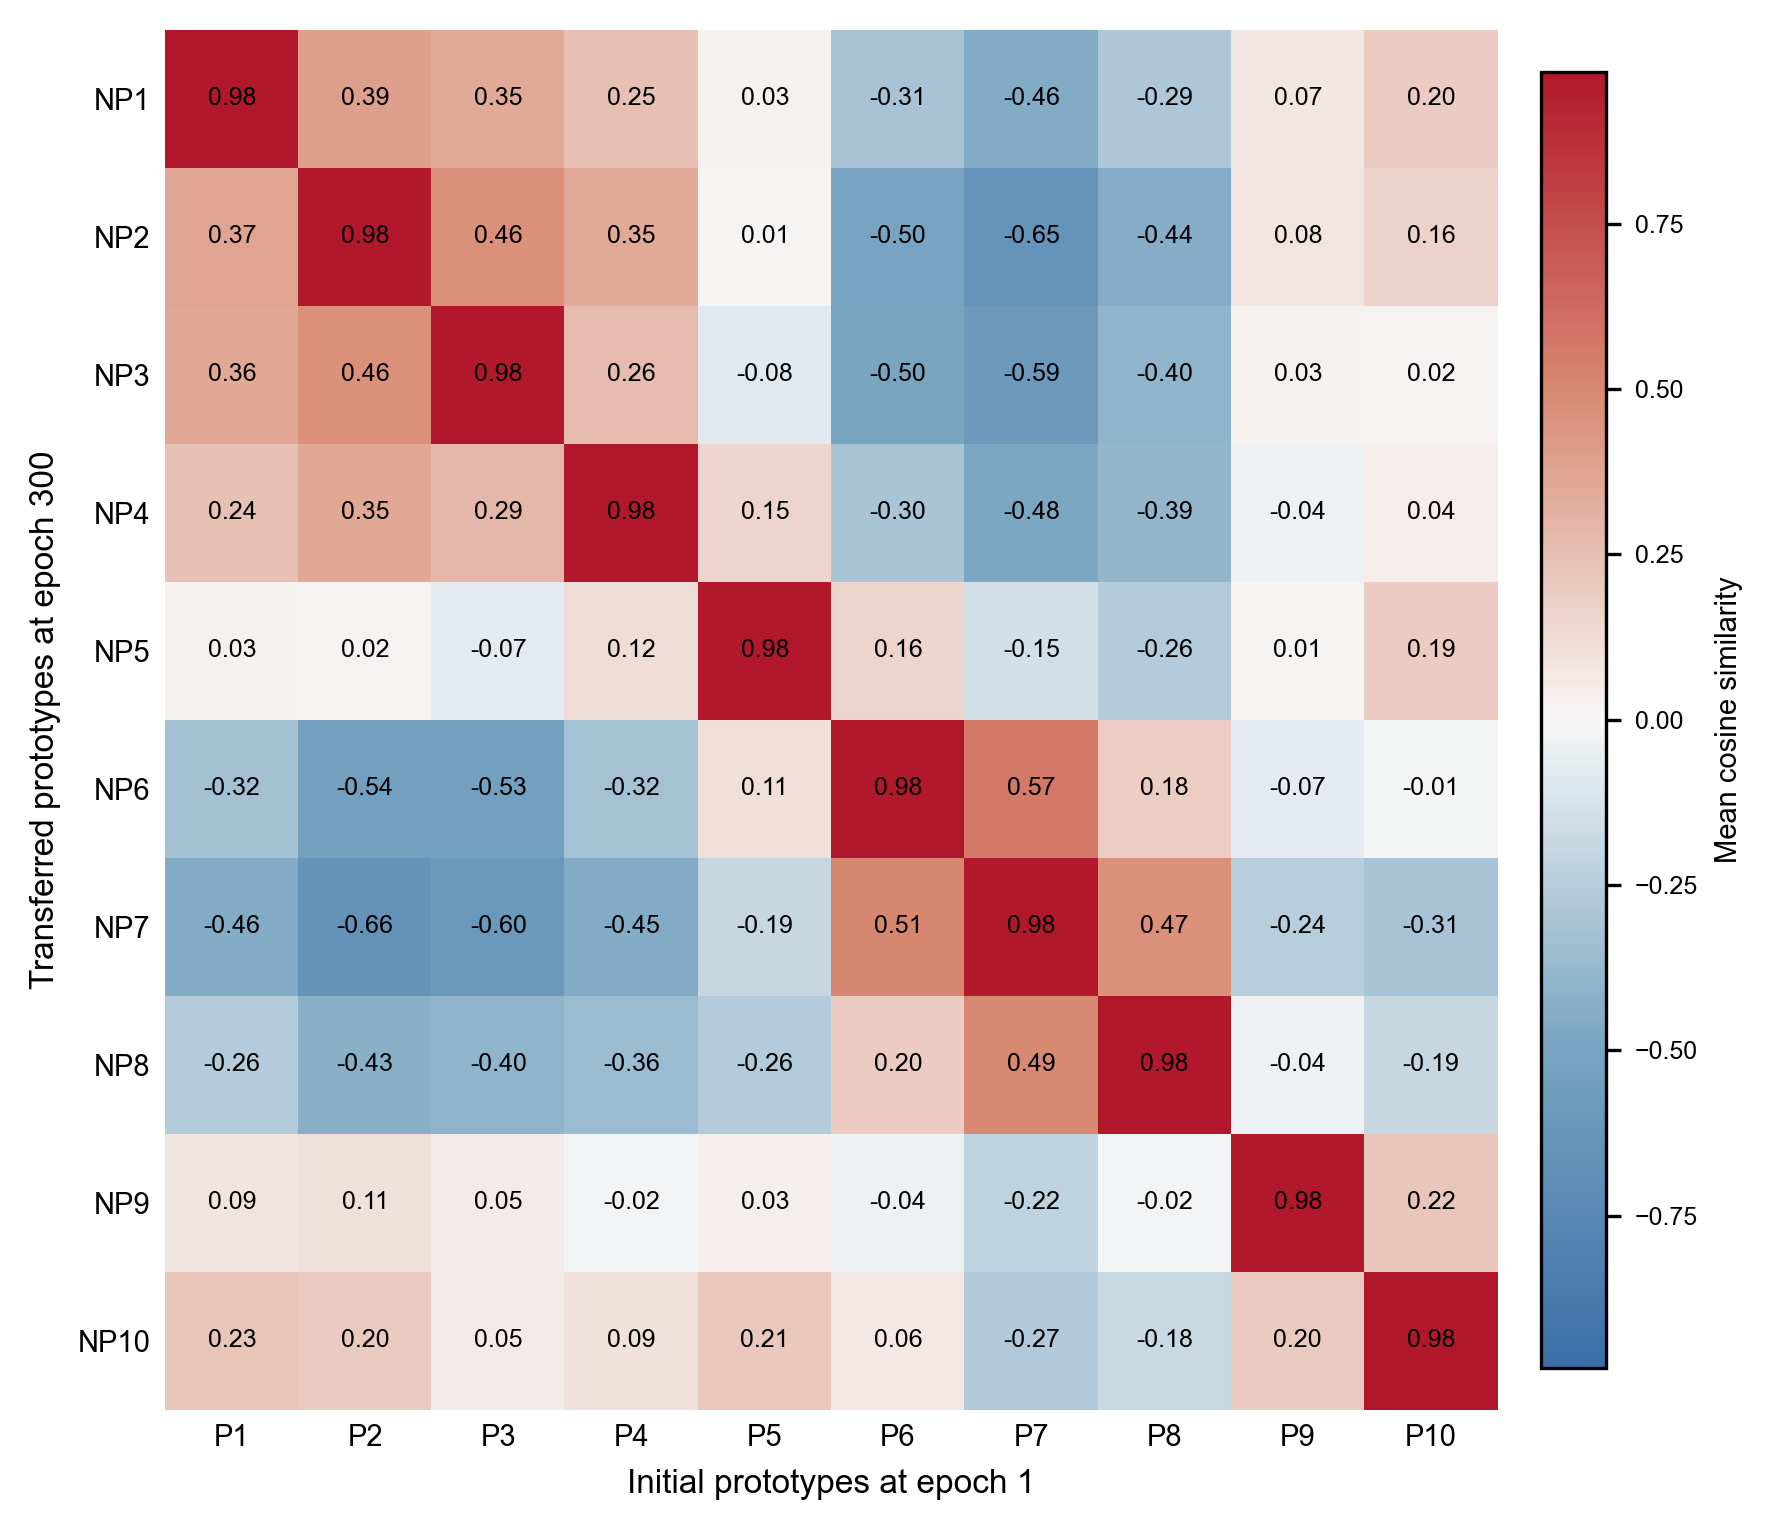

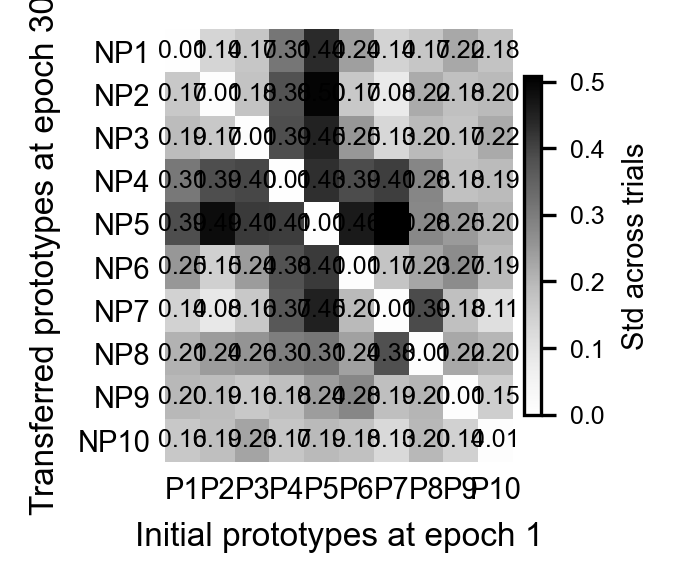


Saved figures:
./save_figs/PCL_old_epoch1_vs_new_epoch300_mean_cosine_similarity.png
./save_figs/PCL_old_epoch1_vs_new_epoch300_mean_cosine_similarity.svg
./save_figs/PCL_old_epoch1_vs_new_epoch300_mean_cosine_similarity.pdf
./save_figs/PCL_old_epoch1_vs_new_epoch300_std_cosine_similarity.png
./save_figs/PCL_old_epoch1_vs_new_epoch300_std_cosine_similarity.svg
./save_figs/PCL_old_epoch1_vs_new_epoch300_std_cosine_similarity.pdf

Saved CSV:
./figs_data/PCL_old_epoch1_vs_new_epoch300_mean_cosine_similarity.csv
./figs_data/PCL_old_epoch1_vs_new_epoch300_std_cosine_similarity.csv
./figs_data/PCL_old_epoch1_vs_new_epoch300_cosine_similarity_all_trials.csv
./figs_data/PCL_old_new_prototype_mapping_summary.csv


In [1]:
# -*- coding: utf-8 -*-

import os
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap


# =========================================================
# 0. Settings
# =========================================================
num_trials = 10
save_path = "/data/hwx/boron/new_proto_save"

old_epoch = 1
new_epoch = 300

fig_save_dir = "./save_figs/"
csv_save_dir = "./figs_data/"
os.makedirs(fig_save_dir, exist_ok=True)
os.makedirs(csv_save_dir, exist_ok=True)

plt.rcParams["font.family"] = "Arial"
plt.rcParams["svg.fonttype"] = "none"
plt.rcParams["pdf.fonttype"] = 42


# =========================================================
# 1. Helper functions
# =========================================================
def load_proto(path):
    p = torch.load(path, map_location="cpu")
    if isinstance(p, torch.Tensor):
        p = p.detach().cpu().numpy()
    else:
        p = np.asarray(p)
    return p.astype(np.float32)


def l2_normalize(x, axis=-1, eps=1e-12):
    norm = np.linalg.norm(x, axis=axis, keepdims=True)
    return x / (norm + eps)


# =========================================================
# 2. Load old/new prototype embeddings for each trial
# =========================================================
all_sim_matrices = []
valid_trials = []

old_proto_all = []
new_proto_all = []

for trial in range(1, num_trials + 1):
    old_path = f"{save_path}/proto_trial_{trial}_epoch_{old_epoch}.pth"
    new_path = f"{save_path}/proto_trial_{trial}_epoch_{new_epoch}.pth"

    if not os.path.exists(old_path):
        print(f"Missing old proto file: {old_path}")
        continue

    if not os.path.exists(new_path):
        print(f"Missing new proto file: {new_path}")
        continue

    old_proto = load_proto(old_path)   # [P, D]
    new_proto = load_proto(new_path)   # [P, D]

    if old_proto.shape != new_proto.shape:
        print(f"Skip trial {trial}: shape mismatch {old_proto.shape} vs {new_proto.shape}")
        continue

    old_proto = l2_normalize(old_proto, axis=1)
    new_proto = l2_normalize(new_proto, axis=1)

    # 行：new prototype，列：old prototype
    sim_matrix = new_proto @ old_proto.T   # [P_new, P_old]

    all_sim_matrices.append(sim_matrix)
    old_proto_all.append(old_proto)
    new_proto_all.append(new_proto)
    valid_trials.append(trial)

    print(f"Trial {trial} loaded. Proto shape: {old_proto.shape}")


if len(all_sim_matrices) == 0:
    raise RuntimeError("No valid trials loaded.")

all_sim_matrices = np.stack(all_sim_matrices, axis=0)  # [T, P, P]
old_proto_all = np.stack(old_proto_all, axis=0)        # [T, P, D]
new_proto_all = np.stack(new_proto_all, axis=0)        # [T, P, D]

T, P, _ = all_sim_matrices.shape

print("\nValid trials:", valid_trials)
print("All similarity matrices shape:", all_sim_matrices.shape)


# =========================================================
# 3. Average similarity across trials
# =========================================================
mean_sim = all_sim_matrices.mean(axis=0)
std_sim = all_sim_matrices.std(axis=0)

old_labels = [f"Old P{i+1}" for i in range(P)]
new_labels = [f"New P{i+1}" for i in range(P)]

mean_sim_df = pd.DataFrame(mean_sim, index=new_labels, columns=old_labels)
std_sim_df = pd.DataFrame(std_sim, index=new_labels, columns=old_labels)

print("\nMean cosine similarity:")
print(mean_sim_df.round(4))

print("\nStd cosine similarity:")
print(std_sim_df.round(4))


# =========================================================
# 4. Save similarity matrices
# =========================================================
mean_sim_df.to_csv(
    os.path.join(csv_save_dir, "PCL_old_epoch1_vs_new_epoch300_mean_cosine_similarity.csv")
)

std_sim_df.to_csv(
    os.path.join(csv_save_dir, "PCL_old_epoch1_vs_new_epoch300_std_cosine_similarity.csv")
)

# 保存每个 trial 的完整矩阵
rows = []

for t_idx, trial in enumerate(valid_trials):
    for i in range(P):
        for j in range(P):
            rows.append({
                "trial": trial,
                "new_prototype": f"New P{i+1}",
                "old_prototype": f"Old P{j+1}",
                "cosine_similarity": all_sim_matrices[t_idx, i, j],
            })

per_trial_df = pd.DataFrame(rows)
per_trial_df.to_csv(
    os.path.join(csv_save_dir, "PCL_old_epoch1_vs_new_epoch300_cosine_similarity_all_trials.csv"),
    index=False
)


# =========================================================
# 5. Best old prototype mapping for each new prototype
# =========================================================
summary_rows = []

for i in range(P):
    row = mean_sim[i]

    best_j = int(np.argmax(row))
    best_sim = row[best_j]

    sorted_row = np.sort(row)[::-1]
    top2_margin = sorted_row[0] - sorted_row[1] if P >= 2 else np.nan

    row_sum = row.sum()

    if row_sum > 0:
        normalized_row = row / row_sum
        recombination_index = 1.0 - normalized_row.max()
        entropy = -np.sum(
            normalized_row[normalized_row > 0] *
            np.log(normalized_row[normalized_row > 0])
        )
        entropy_norm = entropy / np.log(P)
    else:
        recombination_index = np.nan
        entropy_norm = np.nan

    summary_rows.append({
        "new_prototype": f"New P{i+1}",
        "best_matched_old_prototype": f"Old P{best_j+1}",
        "best_mean_cosine_similarity": best_sim,
        "top2_margin": top2_margin,
        "mean_similarity_sum": row_sum,
        "recombination_index": recombination_index,
        "normalized_similarity_entropy": entropy_norm,
    })

summary_df = pd.DataFrame(summary_rows)

summary_df.to_csv(
    os.path.join(csv_save_dir, "PCL_old_new_prototype_mapping_summary.csv"),
    index=False
)

print("\nMapping summary:")
print(summary_df.round(4))


# =========================================================
# 6. Plot mean cosine similarity heatmap
# =========================================================
nature_rb_cmap = LinearSegmentedColormap.from_list(
    "nature_red_blue",
    [
        "#3B6EA8",
        "#7AA6C2",
        "#F7F7F7",
        "#D98B73",
        "#B2182B",
    ]
)

vabs = max(abs(mean_sim.min()), abs(mean_sim.max()))

fig, ax = plt.subplots(figsize=(6.0, 5.2), dpi=300)

im = ax.imshow(
    mean_sim,
    cmap=nature_rb_cmap,
    vmin=-vabs,
    vmax=vabs,
    aspect="auto"
)

ax.set_xticks(np.arange(P))
ax.set_xticklabels([f"P{i+1}" for i in range(P)], fontsize=7)

ax.set_yticks(np.arange(P))
ax.set_yticklabels([f"NP{i+1}" for i in range(P)], fontsize=7)

ax.set_xlabel("Initial prototypes at epoch 1", fontsize=8)
ax.set_ylabel("Transferred prototypes at epoch 300", fontsize=8)

for i in range(P):
    for j in range(P):
        ax.text(
            j,
            i,
            f"{mean_sim[i, j]:.2f}",
            ha="center",
            va="center",
            fontsize=6,
            color="black"
        )

cbar = plt.colorbar(im, ax=ax, fraction=0.045, pad=0.03)
cbar.set_label("Mean cosine similarity", fontsize=7)
cbar.ax.tick_params(labelsize=6)

for spine in ax.spines.values():
    spine.set_visible(False)

ax.tick_params(length=0)

plt.tight_layout()

fig_png = os.path.join(fig_save_dir, "PCL_old_epoch1_vs_new_epoch300_mean_cosine_similarity.png")
fig_svg = os.path.join(fig_save_dir, "PCL_old_epoch1_vs_new_epoch300_mean_cosine_similarity.svg")
fig_pdf = os.path.join(fig_save_dir, "PCL_old_epoch1_vs_new_epoch300_mean_cosine_similarity.pdf")

plt.savefig(fig_png, dpi=600, bbox_inches="tight")
plt.savefig(fig_svg, bbox_inches="tight")
plt.savefig(fig_pdf, bbox_inches="tight")
plt.show()


# =========================================================
# 7. Plot std heatmap
# =========================================================
fig, ax = plt.subplots(figsize=(6.0 / 2.54, 5.2 / 2.54), dpi=300)

im = ax.imshow(
    std_sim,
    cmap="Greys",
    vmin=0,
    vmax=std_sim.max(),
    aspect="auto"
)

ax.set_xticks(np.arange(P))
ax.set_xticklabels([f"P{i+1}" for i in range(P)], fontsize=7)

ax.set_yticks(np.arange(P))
ax.set_yticklabels([f"NP{i+1}" for i in range(P)], fontsize=7)

ax.set_xlabel("Initial prototypes at epoch 1", fontsize=8)
ax.set_ylabel("Transferred prototypes at epoch 300", fontsize=8)

for i in range(P):
    for j in range(P):
        ax.text(
            j,
            i,
            f"{std_sim[i, j]:.2f}",
            ha="center",
            va="center",
            fontsize=6,
            color="black"
        )

cbar = plt.colorbar(im, ax=ax, fraction=0.045, pad=0.03)
cbar.set_label("Std across trials", fontsize=7)
cbar.ax.tick_params(labelsize=6)

for spine in ax.spines.values():
    spine.set_visible(False)

ax.tick_params(length=0)

plt.tight_layout()

fig_png_std = os.path.join(fig_save_dir, "PCL_old_epoch1_vs_new_epoch300_std_cosine_similarity.png")
fig_svg_std = os.path.join(fig_save_dir, "PCL_old_epoch1_vs_new_epoch300_std_cosine_similarity.svg")
fig_pdf_std = os.path.join(fig_save_dir, "PCL_old_epoch1_vs_new_epoch300_std_cosine_similarity.pdf")

plt.savefig(fig_png_std, dpi=600, bbox_inches="tight")
plt.savefig(fig_svg_std, bbox_inches="tight")
plt.savefig(fig_pdf_std, bbox_inches="tight")
plt.show()


print("\nSaved figures:")
print(fig_png)
print(fig_svg)
print(fig_pdf)
print(fig_png_std)
print(fig_svg_std)
print(fig_pdf_std)

print("\nSaved CSV:")
print(os.path.join(csv_save_dir, "PCL_old_epoch1_vs_new_epoch300_mean_cosine_similarity.csv"))
print(os.path.join(csv_save_dir, "PCL_old_epoch1_vs_new_epoch300_std_cosine_similarity.csv"))
print(os.path.join(csv_save_dir, "PCL_old_epoch1_vs_new_epoch300_cosine_similarity_all_trials.csv"))
print(os.path.join(csv_save_dir, "PCL_old_new_prototype_mapping_summary.csv"))

In [1]:
import torch

import torch.nn as nn
import torch.nn.functional as F
from torch.nn import Linear, Dropout, Sequential, ReLU, MultiheadAttention, LayerNorm, BatchNorm1d
from torch_geometric.nn import GraphNorm
from torch_geometric.nn import (
    GraphNorm,
    GCNConv,
    GINEConv,
    GINConv,
    GATConv,
    global_mean_pool
)

class GINE(torch.nn.Module):
    def __init__(self, num_node_features, num_edge_features, hidden_channels, num_classes, dropout):
        super(GINE, self).__init__()

        nn1 = Sequential(Linear(num_node_features, hidden_channels), ReLU(), Linear(hidden_channels, hidden_channels))
        self.conv1 = GINEConv(nn1, edge_dim=num_edge_features)
        self.norm1 = GraphNorm(hidden_channels)

        nn2 = Sequential(Linear(hidden_channels, hidden_channels), ReLU(), Linear(hidden_channels, hidden_channels))
        self.conv2 = GINEConv(nn2, edge_dim=num_edge_features)
        self.norm2 = GraphNorm(hidden_channels)

        nn3 = Sequential(Linear(hidden_channels, hidden_channels), ReLU(), Linear(hidden_channels, hidden_channels))
        self.conv3 = GINEConv(nn3, edge_dim=num_edge_features)
        self.norm3 = GraphNorm(hidden_channels)

        self.dropout = Dropout(dropout)
        # self.batch_norm = BatchNorm1d(hidden_channels)


    def forward(self, x, edge_index, edge_attr, batch): 
        x = self.conv1(x, edge_index, edge_attr)
        x = self.norm1(x)
        x = F.relu(x)
        x = self.dropout(x)

        x = self.conv2(x, edge_index, edge_attr)
        x = self.norm2(x)
        x = F.relu(x)
        x = self.dropout(x)

        x = self.conv3(x, edge_index, edge_attr)
        x = self.norm3(x)
        x = F.relu(x)
        x = self.dropout(x)

        x = global_mean_pool(x, batch)

        # x = self.batch_norm(x)

        return x

class ProjectionHead_PCL(nn.Module):
    def __init__(self, in_dim, proj_dim=128):
        super().__init__()
        self.mlp = nn.Sequential(
            nn.Linear(in_dim, in_dim),
            nn.ReLU(),
            nn.Linear(in_dim, proj_dim),
            nn.BatchNorm1d(proj_dim)
        )

    def forward(self, x):
        return self.mlp(x)

class ProjectionHead(nn.Module):
    def __init__(self, in_dim, proj_dim=128):
        super().__init__()
        self.mlp = nn.Sequential(
            nn.Linear(in_dim, in_dim),
            nn.ReLU(),
            nn.Linear(in_dim, proj_dim),
        )

    def forward(self, x):
        return self.mlp(x)


class Cluster_GINE(torch.nn.Module):
    def __init__(self, num_node_features, num_edge_features, hidden_channels, num_classes, dropout):
        super(Cluster_GINE, self).__init__()

        nn1 = Sequential(Linear(num_node_features, hidden_channels), ReLU(), Linear(hidden_channels, hidden_channels))
        self.conv1 = GINEConv(nn1, edge_dim=num_edge_features)
        self.norm1 = GraphNorm(hidden_channels)

        nn2 = Sequential(Linear(hidden_channels, hidden_channels), ReLU(), Linear(hidden_channels, hidden_channels))
        self.conv2 = GINEConv(nn2, edge_dim=num_edge_features)
        self.norm2 = GraphNorm(hidden_channels)

        nn3 = Sequential(Linear(hidden_channels, hidden_channels), ReLU(), Linear(hidden_channels, hidden_channels))
        self.conv3 = GINEConv(nn3, edge_dim=num_edge_features)
        self.norm3 = GraphNorm(hidden_channels)

        self.dropout = Dropout(dropout)

    def forward(self, x, edge_index, edge_attr, batch): 
        x = self.conv1(x, edge_index, edge_attr)
        x = self.norm1(x)
        x = F.relu(x)
        x = self.dropout(x)

        x = self.conv2(x, edge_index, edge_attr)
        x = self.norm2(x)
        x = F.relu(x)
        x = self.dropout(x)

        x = self.conv3(x, edge_index, edge_attr)
        x = self.norm3(x)
        x = F.relu(x)
        x = self.dropout(x)

        x = global_mean_pool(x, batch)

        return x

class Cluster_GCN(torch.nn.Module):
    def __init__(self, num_node_features, num_edge_features, hidden_channels, num_classes, dropout):
        super(Cluster_GCN, self).__init__()

        self.conv1 = GCNConv(num_node_features, hidden_channels)
        self.norm1 = GraphNorm(hidden_channels)

        self.conv2 = GCNConv(hidden_channels, hidden_channels)
        self.norm2 = GraphNorm(hidden_channels)

        self.conv3 = GCNConv(hidden_channels, hidden_channels)
        self.norm3 = GraphNorm(hidden_channels)

        self.dropout = Dropout(dropout)

    def forward(self, x, edge_index, edge_attr, batch):
        # GCN 不使用 edge_attr
        x = self.conv1(x, edge_index)
        x = self.norm1(x)
        x = F.relu(x)
        x = self.dropout(x)

        x = self.conv2(x, edge_index)
        x = self.norm2(x)
        x = F.relu(x)
        x = self.dropout(x)

        x = self.conv3(x, edge_index)
        x = self.norm3(x)
        x = F.relu(x)
        x = self.dropout(x)

        x = global_mean_pool(x, batch)

        return x

class Cluster_GIN(torch.nn.Module):
    def __init__(self, num_node_features, num_edge_features, hidden_channels, num_classes, dropout):
        super(Cluster_GIN, self).__init__()

        nn1 = Sequential(
            Linear(num_node_features, hidden_channels),
            ReLU(),
            Linear(hidden_channels, hidden_channels)
        )
        self.conv1 = GINConv(nn1)
        self.norm1 = GraphNorm(hidden_channels)

        nn2 = Sequential(
            Linear(hidden_channels, hidden_channels),
            ReLU(),
            Linear(hidden_channels, hidden_channels)
        )
        self.conv2 = GINConv(nn2)
        self.norm2 = GraphNorm(hidden_channels)

        nn3 = Sequential(
            Linear(hidden_channels, hidden_channels),
            ReLU(),
            Linear(hidden_channels, hidden_channels)
        )
        self.conv3 = GINConv(nn3)
        self.norm3 = GraphNorm(hidden_channels)

        self.dropout = Dropout(dropout)

    def forward(self, x, edge_index, edge_attr, batch):
        # GIN 不使用 edge_attr
        x = self.conv1(x, edge_index)
        x = self.norm1(x)
        x = F.relu(x)
        x = self.dropout(x)

        x = self.conv2(x, edge_index)
        x = self.norm2(x)
        x = F.relu(x)
        x = self.dropout(x)

        x = self.conv3(x, edge_index)
        x = self.norm3(x)
        x = F.relu(x)
        x = self.dropout(x)

        x = global_mean_pool(x, batch)

        return x

class Cluster_GAT(torch.nn.Module):
    def __init__(self, num_node_features, num_edge_features, hidden_channels, num_classes, dropout, heads=4):
        super(Cluster_GAT, self).__init__()

        self.conv1 = GATConv(
            in_channels=num_node_features,
            out_channels=hidden_channels,
            heads=heads,
            concat=False,
            dropout=dropout,
            edge_dim=num_edge_features
        )
        self.norm1 = GraphNorm(hidden_channels)

        self.conv2 = GATConv(
            in_channels=hidden_channels,
            out_channels=hidden_channels,
            heads=heads,
            concat=False,
            dropout=dropout,
            edge_dim=num_edge_features
        )
        self.norm2 = GraphNorm(hidden_channels)

        self.conv3 = GATConv(
            in_channels=hidden_channels,
            out_channels=hidden_channels,
            heads=heads,
            concat=False,
            dropout=dropout,
            edge_dim=num_edge_features
        )
        self.norm3 = GraphNorm(hidden_channels)

        self.dropout = Dropout(dropout)

    def forward(self, x, edge_index, edge_attr, batch):
        # GAT 可以使用 edge_attr
        x = self.conv1(x, edge_index, edge_attr=edge_attr)
        x = self.norm1(x)
        x = F.relu(x)
        x = self.dropout(x)

        x = self.conv2(x, edge_index, edge_attr=edge_attr)
        x = self.norm2(x)
        x = F.relu(x)
        x = self.dropout(x)

        x = self.conv3(x, edge_index, edge_attr=edge_attr)
        x = self.norm3(x)
        x = F.relu(x)
        x = self.dropout(x)

        x = global_mean_pool(x, batch)

        return x

In [2]:
import torch
import argparse
import pickle
from torch_geometric.loader import DataLoader
from tqdm import tqdm
import pandas as pd
import torch.nn.functional as F
from sklearn.metrics import silhouette_score
import umap
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split


parser = argparse.ArgumentParser(description="Train a GCN model")
# unsupervised learning configs
parser = argparse.ArgumentParser(description="Train the model")
parser.add_argument('--analysis', type=bool, default=False, help='Wether to print the summary of the dataset')
parser.add_argument('--usl_batch_size', type=int, default=256, help='Batch size for training')
parser.add_argument('--num_classes', type=int, default=2, help='Number of classes')
parser.add_argument('--usl_learning_rate', type=float, default=0.0005, help='Learning rate')
parser.add_argument('--usl_hidden_channels', type=int, default=256, help='Number of hidden channels')
parser.add_argument('--epoch', type=int, default=200, help='Number of training epochs')
parser.add_argument('--dropout', type=float, default=0.5, help='Value of dropout')
parser.add_argument('--training_types', type=str, default='Unsupervised learning', help='training_types')
parser.add_argument('--models', type=str, default='GINE', help='Training models')
parser.add_argument('--embed_dim', type=int, default=256, help='Embedding dimension of attention')
parser.add_argument('--num_heads', type=int, default=4, help='Number of heads for attention')
parser.add_argument('--desp_dim', type=int, default=217, help='Number of descriptors')
parser.add_argument('--retrain_usl', type=bool, default=False, help='retrain the usl models')
parser.add_argument('--ucl_trials', type=int, default=10, help='Number of trials for unsupervised learning')
parser.add_argument('--save_path', type=str, default='checkpoints', help='')

# graph augmentation configs
parser.add_argument('--aug_types', type=str, default='all', help='augmentation types')
parser.add_argument('--shuffle_ratio', type=float, default=0.2, help='shuffle ratio')
parser.add_argument('--node_drop_ratio', type=float, default=0.2, help='node drop ratio')
parser.add_argument('--noise_ratio', type=float, default=0.2, help='noise_ratio')
parser.add_argument('--noise_std', type=float, default=0.1, help='noise_std')
parser.add_argument('--edge_drop_ratio', type=float, default=0.1, help='edge drop ratio')
parser.add_argument('--edge_add_ratio', type=float, default=0.05, help='edge add ratio')
parser.add_argument('--alpha', type=float, default=0.15, help='PPR alpha')
parser.add_argument('--PPR_drop_ratio', type=float, default=0.2, help='PPR_drop_ratio')
parser.add_argument('--PPR_add_ratio', type=float, default=0.2, help='PPR_add_ratio')
parser.add_argument('--K', type=int, default=10, help='PPR K')
parser.add_argument('--random_state', type=int, default=42, help='data split random seed')
parser.add_argument('--test_size', type=float, default=0.2, help='test set size')


# prototypes configs
parser.add_argument('--max_cluster', type=int, default=10, help='max cluster number')
parser.add_argument('--temperature', type=float, default=0.1, help='temperature coefficient for prototypes')
parser.add_argument('--proto_epoch', type=int, default=300, help='Number of training epochs')
parser.add_argument('--r', type=int, default=10000, help='number of randomly select neg prototypes')
parser.add_argument('--proto_training_types', type=str, default='Prototype contrastive learning', help='training_types')
parser.add_argument('--proto_models', type=str, default='GINE', help='model name for PCL')
parser.add_argument('--pcl_hidden_channels', type=int, default=256, help='Number of hidden channels')
parser.add_argument('--pcl_learning_rate', type=float, default=0.00001, help='Learning rate')
parser.add_argument('--pcl_batch_size', type=int, default=1024, help='Batch size for training')
parser.add_argument('--threshold', type=float, default=0.3, help='threshold')
parser.add_argument('--topk', type=int, default=25, help='top k samples for each prototype')

args = parser.parse_args(args=[])
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')



def load_data(data_path):
    # data preparation
    with open(data_path, 'rb') as f:
        all_data = pickle.load(f)

    positive_samples = all_data[:126] # number of positive samples
    unlabeled_samples = all_data[126:]

    unl_train_samples, unl_test_samples = train_test_split(unlabeled_samples, test_size=args.test_size, random_state=args.random_state)
    return positive_samples, unlabeled_samples, unl_train_samples, unl_test_samples

data_path = '/home/hwx/python_project/test/Boron/data/all_data.pkl'
file_path = f"/home/hwx/python_project/test/Boron/{args.save_path}_origin_backup/{args.training_types}_model_{args.models}.pth"

# load data
positive_samples_126, unlabeled_samples, unl_train_samples, unl_test_samples = load_data(data_path)

pos_loader = DataLoader(positive_samples_126, batch_size=args.pcl_batch_size, shuffle=False)
unl_loader = DataLoader(unl_train_samples + unl_test_samples, batch_size=args.pcl_batch_size, shuffle=False)



encoder = GINE(num_node_features=positive_samples_126[0].x.shape[1], num_edge_features=positive_samples_126[0].edge_attr.shape[1], 
        hidden_channels=args.pcl_hidden_channels,
        num_classes=args.num_classes, dropout=args.dropout).to(device)
projection = ProjectionHead_PCL(in_dim=args.pcl_hidden_channels).to(device)
encoder.load_state_dict(torch.load(f'/home/hwx/python_project/test/Boron/{args.save_path}_origin_backup/encoder_{args.proto_models}_epoch_{args.proto_epoch}.pth')) # load the checkpoints
projection.load_state_dict(torch.load(f'/home/hwx/python_project/test/Boron/{args.save_path}_origin_backup/projection_{args.proto_models}_epoch_{args.proto_epoch}.pth')) # load the checkpoints
proto_centroids = torch.load(f'/home/hwx/python_project/test/Boron/{args.save_path}_origin_backup/proto_centroids_{args.proto_models}_epoch_{args.proto_epoch}.pth')
print('Loaded the prototype contrastive learning encoder...')


def get_embeddings(encoder, projection, dataloader, proto_centroids):
    encoder.eval()
    projection.eval()
    all_embeddings = []
    all_ids = []

    with torch.no_grad():
        for data in tqdm(dataloader):
            data = data.to(device)
            proto_centroids = proto_centroids.to(device)

            query = encoder(data.x, data.edge_index, data.edge_attr, data.batch)
            query = projection(query)
            query = F.normalize(query, dim=-1)
            all_ids.append(data.id.cpu())
            all_embeddings.append(query.cpu())

    all_embeddings = torch.cat(all_embeddings, dim=0)
    all_ids = torch.cat(all_ids, dim=0)

    return all_embeddings, all_ids


emb_unl, unl_ids = get_embeddings(encoder, projection, unl_loader, proto_centroids)



Loaded the prototype contrastive learning encoder...


100%|██████████| 176/176 [00:09<00:00, 18.05it/s]


Starting Prototype Attraction Analysis...
Embedding shape: (179825, 128)
Prototype shape: (7, 128)
Top 25% molecules: 30800
Mann-Whitney U test p-value: 0.0


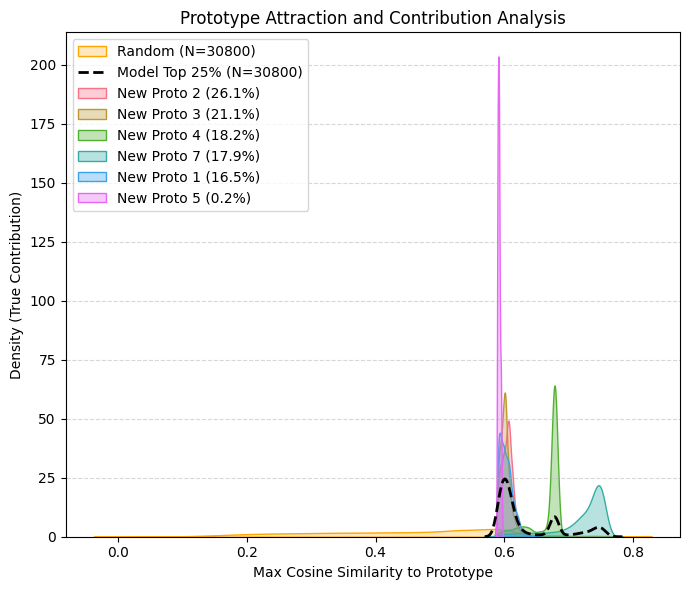

In [4]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from scipy.stats import mannwhitneyu

print("Starting Prototype Attraction Analysis...")

# ==============================
# 1 Convert tensor to numpy
# ==============================

emb = emb_unl.numpy()
proto = proto_centroids.detach().cpu().numpy()
mol_ids = unl_ids.numpy()

print("Embedding shape:", emb.shape)
print("Prototype shape:", proto.shape)

# ==============================
# 2 Similarity matrix
# ==============================

# cosine similarity (embedding already normalized)
sim_matrix = emb @ proto.T   # [N_molecules, N_prototypes]

# closest prototype
closest_proto = np.argmax(sim_matrix, axis=1)

# similarity to closest prototype
max_sim = np.max(sim_matrix, axis=1)

# ==============================
# 3 Model recommended molecules (修改部分)
# ==============================

top_ratio = 0.25
top_n = 30800

top_idx = np.argsort(max_sim)[-top_n:]

sim_top = max_sim[top_idx]
proto_top = closest_proto[top_idx]

print(f"Top {top_ratio*100:.0f}% molecules:", top_n)

# ==============================
# 4 Random baseline
# ==============================
random_idx = np.random.choice(len(max_sim), top_n, replace=False)
sim_random = max_sim[random_idx]

# ==============================
# 5 Statistical test
# ==============================
stat, p_value = mannwhitneyu(sim_top, sim_random)
print("Mann-Whitney U test p-value:", p_value)

# ==============================
# 6 Prototype 贡献分析
# ==============================
proto_counts = Counter(proto_top)
top_k_protos = [item[0] for item in proto_counts.most_common(len(proto_counts))]

# ==============================
# 7 权重（关键！！！）
# ==============================
N_total = len(max_sim)

weights_top = np.ones_like(sim_top) / N_total
weights_random = np.ones_like(sim_random) / N_total

# ==============================
# 8 Plot
# ==============================
plt.figure(figsize=(7,6))

# ===== Random =====
sns.kdeplot(
    x=sim_random,
    weights=weights_random,
    label=f"Random (N={len(sim_random)})",
    fill=True,
    color='orange',
    alpha=0.25,
    bw_adjust=1.2,
    common_norm=False
)

# ===== Model 总体 =====
sns.kdeplot(
    x=sim_top,
    weights=weights_top,
    label=f"Model Top 25% (N={len(sim_top)})",
    color='black',
    lw=2,
    linestyle='--',
    common_norm=False
)

# ===== Prototype 分解 =====
colors = sns.color_palette("husl", len(top_k_protos))

for i, p_id in enumerate(top_k_protos):
    subset_sim = sim_top[proto_top == p_id]

    count = len(subset_sim)
    percentage = count / len(sim_top) * 100

    weights_subset = np.ones_like(subset_sim) / N_total

    sns.kdeplot(
        x=subset_sim,
        weights=weights_subset,
        label=f"New Proto {p_id+1} ({percentage:.1f}%)",
        fill=True,
        alpha=0.35,
        color=colors[i],
        common_norm=False
    )

# ==============================
# 美化
# ==============================
plt.xlabel("Max Cosine Similarity to Prototype")
plt.ylabel("Density (True Contribution)")

plt.title("Prototype Attraction and Contribution Analysis")

plt.legend(loc='best')
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()


# ==============================
# 🔥 导出当前图对应的KDE数据（不改原图）
# ==============================

from scipy.stats import gaussian_kde

# 和 seaborn 一致的 x 轴范围
xmin = min(max_sim)
xmax = max(max_sim)
x_grid = np.linspace(xmin, xmax, 400)

def compute_kde(x, weights, bw_adjust=1.2):
    if len(x) < 2:
        return np.zeros_like(x_grid)
    
    kde = gaussian_kde(x, weights=weights)
    kde.set_bandwidth(kde.factor * bw_adjust)  # 对齐 seaborn
    
    return kde(x_grid)

# ===== Random =====
kde_random = compute_kde(sim_random, weights_random)

# ===== Model =====
kde_model = compute_kde(sim_top, weights_top)

# ===== Prototype =====
proto_kde_dict = {}

for p_id in top_k_protos:
    subset_sim = sim_top[proto_top == p_id]
    weights_subset = np.ones_like(subset_sim) / N_total
    
    kde_vals = compute_kde(subset_sim, weights_subset)
    proto_kde_dict[p_id] = kde_vals

# ==============================
# 构建 DataFrame
# ==============================
data_dict = {
    "similarity": x_grid,
    "random": kde_random,
    "model": kde_model
}

for p_id in top_k_protos:
    data_dict[f"proto_{p_id}"] = proto_kde_dict[p_id]

df = pd.DataFrame(data_dict)


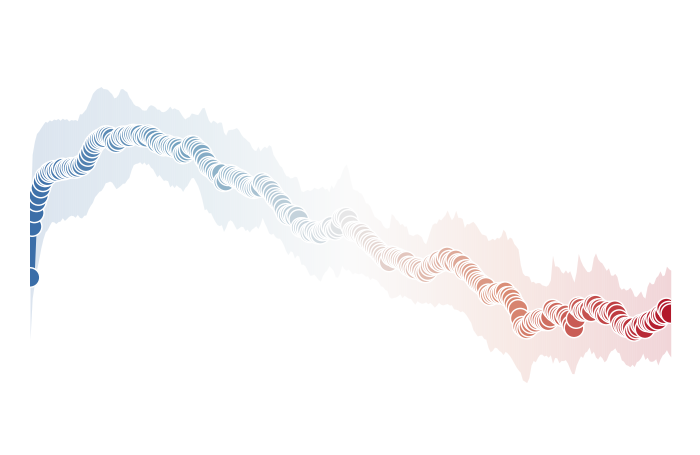

Saved figure: ./save_figs/fig4_b.svg


In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.collections import LineCollection
from matplotlib.colors import LinearSegmentedColormap, Normalize

# =========================
# 路径
# =========================
data_dir = "./figs_data/"
fig_save_dir = "./save_figs/"
os.makedirs(fig_save_dir, exist_ok=True)

csv_path = os.path.join(data_dir, "fig4_b.csv")
df = pd.read_csv(csv_path)

# =========================
# Nature red-blue colormap
# =========================
nature_rb_cmap = LinearSegmentedColormap.from_list(
    "nature_red_blue",
    [
        "#3B6EA8",  # muted blue
        "#7AA6C2",  # light blue
        "#E8E8E8",  # soft neutral
        "#D98B73",  # soft red-orange
        "#B2182B",  # deep red
    ],
)

# =========================
# Data
# =========================
x = df["epoch"].values
y = df["mean_drift"].values
std = df["std_drift"].values

norm = Normalize(vmin=x.min(), vmax=x.max())

# =========================
# Figure size: 7 cm × 4.35 cm
# =========================
cm_to_inch = 1 / 2.54
fig, ax = plt.subplots(
    figsize=(7 * cm_to_inch, 4.35 * cm_to_inch),
    dpi=300
)

plt.rcParams["font.family"] = "Arial"
plt.rcParams["svg.fonttype"] = "none"

# =========================
# Gradient line
# =========================
points = np.array([x, y]).T.reshape(-1, 1, 2)
segments = np.concatenate([points[:-1], points[1:]], axis=1)

lc = LineCollection(
    segments,
    cmap=nature_rb_cmap,
    norm=norm,
    linewidth=2.2
)
lc.set_array(x[:-1])
ax.add_collection(lc)

# =========================
# Scatter points
# =========================
ax.scatter(
    x, y,
    s=22,
    marker="o",
    c=x,
    cmap=nature_rb_cmap,
    norm=norm,
    edgecolors="white",
    linewidths=0.35,
    zorder=2
)

# =========================
# Gradient error band
# =========================
for i in range(len(x) - 1):
    color = nature_rb_cmap(norm((x[i] + x[i + 1]) / 2))
    ax.fill_between(
        x[i:i + 2],
        (y - std)[i:i + 2],
        (y + std)[i:i + 2],
        color=color,
        alpha=0.18,
        linewidth=0
    )

# =========================
# Limits
# =========================
ax.set_xlim(x.min(), x.max())
ax.set_ylim((y - std).min() * 0.95, (y + std).max() * 1.05)

# =========================
# Remove all axes, ticks, labels, grid, background
# =========================
ax.set_axis_off()
ax.grid(False)
ax.set_xticks([])
ax.set_yticks([])
ax.set_xlabel("")
ax.set_ylabel("")

fig.patch.set_alpha(0)
ax.patch.set_alpha(0)

# =========================
# Save SVG
# =========================
fig_path = os.path.join(fig_save_dir, "fig4_b.svg")

plt.savefig(
    fig_path,
    format="svg",
    dpi=300,
    transparent=True,
    bbox_inches="tight",
    pad_inches=0
)

plt.show()

print("Saved figure:", fig_path)

Prototype shape: torch.Size([7, 128])
PCL N = 71 mean = 0.78983986 median = 0.8040538 std = 0.030611737
PCL encoder only N = 404 mean = 0.72864676 median = 0.7290864 std = 0.045722723
PCL clustering N = 341 mean = 0.5711334 median = 0.5703428 std = 0.110498585
USL encoder only N = 1622 mean = 0.08542905 median = 0.08323064 std = 0.010821659
USL clustering N = 155 mean = 0.07985253 median = 0.077094376 std = 0.02117422
Morgan N = 1598 mean = 0.4970982 median = 0.49012202 std = 0.17715707
Random N = 647 mean = 0.5217479 median = 0.5297628 std = 0.14780416
Saved CSV: ./figs_data/fig4_c.csv


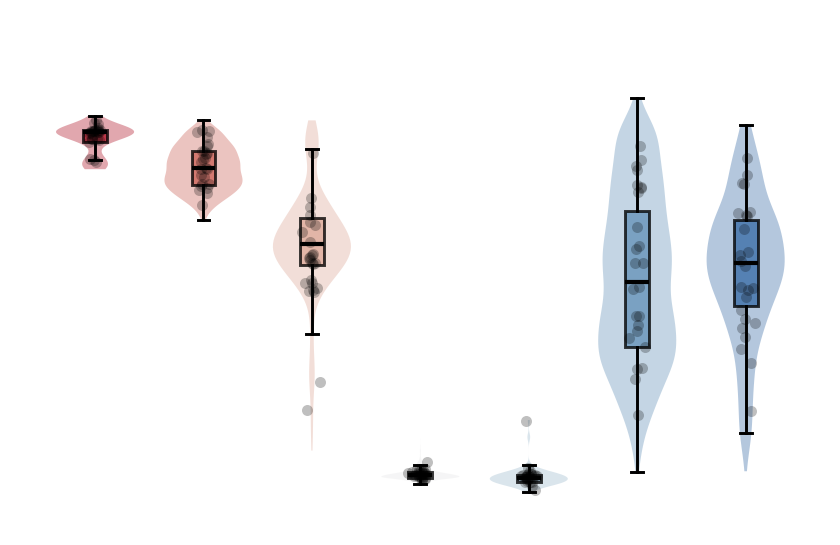

Saved figure: ./save_figs/fig4_c.svg


In [4]:
import os
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch.nn.functional as F
from matplotlib.colors import LinearSegmentedColormap

# =========================
# 路径
# =========================
data_dir = "../outputs"

emb_files = {
    "PCL": "embeddings_after_post_screening_full_model_ema_True_decor_True_topk_True.npy",
    "PCL encoder only": "embeddings_after_post_screening_pcl_encoder_only_ema_True_decor_True_topk_True.npy",
    "PCL clustering": "embeddings_after_post_screening_pcl_encoder_clustering_ema_True_decor_True_topk_True.npy",
    "USL encoder only": "embeddings_after_post_screening_usl_encoder_only_ema_True_decor_True_topk_True.npy",
    "USL clustering": "embeddings_after_post_screening_usl_encoder_clustering_ema_True_decor_True_topk_True.npy",
    "Morgan": "embeddings_after_post_screening_morgan_ema_True_decor_True_topk_True.npy",
    "Random": "embeddings_after_post_screening_random.npy",
}

proto_path = os.path.join(
    "../ablation_checkpoints/",
    "proto_centroids_full_model_ema_True_decor_True_topk_True.pth"
)

save_dir = "./save_figs/"
os.makedirs(save_dir, exist_ok=True)
os.makedirs("./figs_data", exist_ok=True)

# =========================
# 读取 prototype
# =========================
protos = torch.load(proto_path, map_location="cpu")

if isinstance(protos, dict):
    for k, v in protos.items():
        if torch.is_tensor(v):
            protos = v
            print("Loaded prototype tensor from key:", k)
            break

protos = torch.as_tensor(protos, dtype=torch.float32)
protos = F.normalize(protos, dim=1)

print("Prototype shape:", protos.shape)

# =========================
# 计算 nearest prototype similarity
# =========================
all_rows = []

for method, fname in emb_files.items():

    emb_path = os.path.join(data_dir, fname)

    if not os.path.exists(emb_path):
        print(f"[Skip] File not found: {emb_path}")
        continue

    emb = np.load(emb_path)
    emb = torch.as_tensor(emb, dtype=torch.float32)
    emb = F.normalize(emb, dim=1)

    sim_matrix = emb @ protos.T
    max_sim, assign = sim_matrix.max(dim=1)

    max_sim = max_sim.cpu().numpy()
    assign = assign.cpu().numpy() + 1

    print(
        method,
        "N =", len(max_sim),
        "mean =", max_sim.mean(),
        "median =", np.median(max_sim),
        "std =", max_sim.std()
    )

    for s, a in zip(max_sim, assign):
        all_rows.append({
            "method": method,
            "nearest_proto_similarity": float(s),
            "assigned_prototype": int(a)
        })

df = pd.DataFrame(all_rows)

csv_path = os.path.join("./figs_data", "fig4_c.csv")
df.to_csv(csv_path, index=False)
print("Saved CSV:", csv_path)

# =========================
# Nature red-blue colormap
# =========================
nature_rb_cmap = LinearSegmentedColormap.from_list(
    "nature_red_blue",
    [
        "#B2182B",  # deep red
        "#D98B73",  # soft red-orange
        "#E8E8E8",  # soft neutral
        "#7AA6C2",  # light blue
        "#3B6EA8",  # muted blue
    ],
)

# =========================
# Plot data
# =========================
plt.rcParams["font.family"] = "Arial"
plt.rcParams["svg.fonttype"] = "none"

plot_order = [
    "PCL",
    "PCL encoder",
    "PCL clustering",
    "USL encoder",
    "USL clustering",
    "Morgan",
    "Random",
]

rename_map = {
    "PCL": "PCL",
    "PCL encoder only": "PCL encoder",
    "PCL clustering": "PCL clustering",
    "USL encoder only": "USL encoder",
    "USL clustering": "USL clustering",
    "Morgan": "Morgan",
    "Random": "Random",
}

df_plot = df.copy()
df_plot["method_short"] = df_plot["method"].map(rename_map)

data = [
    df_plot.loc[df_plot["method_short"] == m, "nearest_proto_similarity"].values
    for m in plot_order
]

# 从 blue → red 给 7 组方法分配颜色
colors = {
    method: nature_rb_cmap(i / (len(plot_order) - 1))
    for i, method in enumerate(plot_order)
}

# =========================
# Figure size: 6.61 cm × 4.11 cm
# =========================
cm_to_inch = 1 / 2.54

fig, ax = plt.subplots(
    figsize=(6.61 * cm_to_inch, 4.11 * cm_to_inch),
    dpi=300
)

positions = np.arange(len(plot_order))

# =========================
# Violin
# =========================
vp = ax.violinplot(
    data,
    positions=positions,
    widths=0.72,
    showmeans=False,
    showmedians=False,
    showextrema=False
)

for body, method in zip(vp["bodies"], plot_order):
    body.set_facecolor(colors[method])
    body.set_edgecolor("none")
    body.set_alpha(0.38)

# =========================
# Boxplot
# =========================
bp = ax.boxplot(
    data,
    positions=positions,
    widths=0.22,
    patch_artist=True,
    showfliers=False,
    medianprops=dict(color="black", linewidth=1.0),
    whiskerprops=dict(color="black", linewidth=0.7),
    capprops=dict(color="black", linewidth=0.7),
)

for patch, method in zip(bp["boxes"], plot_order):
    patch.set_facecolor(colors[method])
    patch.set_alpha(0.78)
    patch.set_edgecolor("black")
    patch.set_linewidth(0.7)

# =========================
# Jitter points
# =========================
np.random.seed(42)
max_points_per_group = 25

for i, values in enumerate(data):

    values = np.asarray(values)

    if len(values) > max_points_per_group:
        values_show = np.random.choice(
            values,
            size=max_points_per_group,
            replace=False
        )
    else:
        values_show = values

    jitter = np.random.normal(
        loc=0,
        scale=0.035,
        size=len(values_show)
    )

    ax.scatter(
        np.full_like(values_show, positions[i], dtype=float) + jitter,
        values_show,
        s=7,
        color="black",
        alpha=0.25,
        linewidth=0,
        zorder=3
    )

# =========================
# Limits
# =========================
ax.set_xlim(-0.6, len(plot_order) - 0.4)
ax.set_ylim(0, 1.02)

# =========================
# 删除所有数值、坐标轴、刻度、背景
# =========================
ax.set_axis_off()
ax.grid(False)
ax.set_xticks([])
ax.set_yticks([])
ax.set_xlabel("")
ax.set_ylabel("")

fig.patch.set_alpha(0)
ax.patch.set_alpha(0)

plt.subplots_adjust(left=0, right=1, top=1, bottom=0)

# =========================
# Save SVG
# =========================
fig_path = os.path.join(save_dir, "fig4_c.svg")

plt.savefig(
    fig_path,
    format="svg",
    dpi=600,
    transparent=True,
    bbox_inches="tight",
    pad_inches=0
)

plt.show()

print("Saved figure:", fig_path)

Loading prototype centroids...
Prototype centroids shape: (7, 128)
Evaluating Full model...
Evaluating Random selection...
Evaluating Morgan fingerprints...
Evaluating PCL encoder only...
Evaluating USL encoder only...
Evaluating PCL encoder clustering...
Evaluating USL encoder clustering...
Evaluating w/o EMA...
Evaluating w/o decorrelation...
Evaluating w/o top-K...

Assignment quality summary:
                Method  Candidate number  Prototype similarity mean  Prototype similarity std  Assignment entropy  Normalized assignment entropy  Assignment quality  P1 count  P1 ratio  P2 count  P2 ratio  P3 count  P3 ratio  P4 count  P4 ratio  P5 count  P5 ratio  P6 count  P6 ratio  P7 count  P7 ratio
            Full model                78                   0.788646                  0.031378            1.459438                       0.750003            0.591487        15  0.192308         6  0.076923         8  0.102564         0  0.000000        19  0.243590        30  0.384615         0 

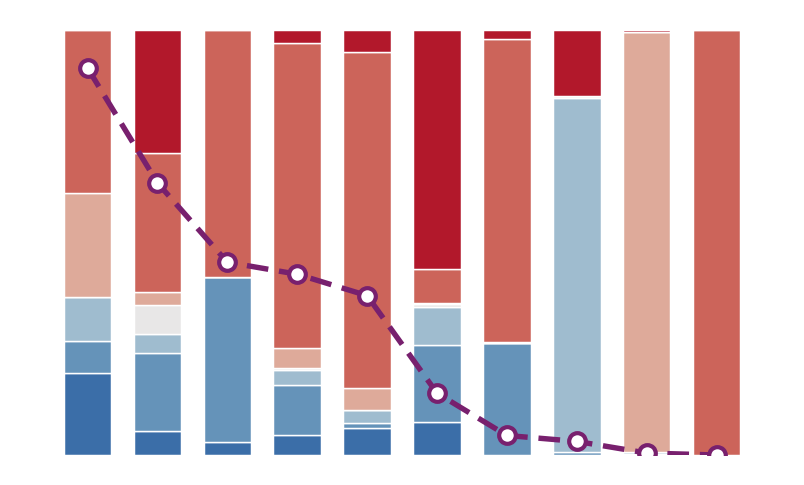

Saved figure:
./save_figs/fig4_d.svg

Saved data:
./figs_data/fig4_d.csv
./figs_data/fig4_d.csv


In [2]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-

import os
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from sklearn.preprocessing import normalize


# ============================================================
# 1. 文件路径
# ============================================================

FULL_CSV = r"../outputs/recommendations_after_post_screening_full_model_ema_True_decor_True_topk_True_year_all.csv"
RANDOM_CSV = r"../outputs/recommendations_after_post_screening_random.csv"
MORGAN_CSV = r"../outputs/recommendations_after_post_screening_morgan_ema_True_decor_True_topk_True.csv"

PCL_ENCODER_ONLY_CSV = r"../outputs/recommendations_after_post_screening_pcl_encoder_only_ema_True_decor_True_topk_True.csv"
USL_ENCODER_ONLY_CSV = r"../outputs/recommendations_after_post_screening_usl_encoder_only_ema_True_decor_True_topk_True.csv"

PCL_ENCODER_CLUSTERING_CSV = r"../outputs/recommendations_after_post_screening_pcl_encoder_clustering_ema_True_decor_True_topk_True.csv"
USL_ENCODER_CLUSTERING_CSV = r"../outputs/recommendations_after_post_screening_usl_encoder_clustering_ema_True_decor_True_topk_True.csv"

WO_EMA_CSV = r"../outputs/recommendations_after_post_screening_full_model_ema_False_decor_True_topk_True.csv"
WO_DECOR_CSV = r"../outputs/recommendations_after_post_screening_full_model_ema_True_decor_False_topk_True.csv"
WO_TOPK_CSV = r"../outputs/recommendations_after_post_screening_full_model_ema_True_decor_True_topk_False.csv"

FULL_EMB = r"../outputs/embeddings_after_post_screening_full_model_ema_True_decor_True_topk_True_year_all.npy"
RANDOM_EMB = r"../outputs/embeddings_after_post_screening_random.npy"
MORGAN_EMB = r"../outputs/embeddings_after_post_screening_morgan_ema_True_decor_True_topk_True.npy"

PCL_ENCODER_ONLY_EMB = r"../outputs/embeddings_after_post_screening_pcl_encoder_only_ema_True_decor_True_topk_True.npy"
USL_ENCODER_ONLY_EMB = r"../outputs/embeddings_after_post_screening_usl_encoder_only_ema_True_decor_True_topk_True.npy"

PCL_ENCODER_CLUSTERING_EMB = r"../outputs/embeddings_after_post_screening_pcl_encoder_clustering_ema_True_decor_True_topk_True.npy"
USL_ENCODER_CLUSTERING_EMB = r"../outputs/embeddings_after_post_screening_usl_encoder_clustering_ema_True_decor_True_topk_True.npy"

WO_EMA_EMB = r"../outputs/embeddings_after_post_screening_full_model_ema_False_decor_True_topk_True.npy"
WO_DECOR_EMB = r"../outputs/embeddings_after_post_screening_full_model_ema_True_decor_False_topk_True.npy"
WO_TOPK_EMB = r"../outputs/embeddings_after_post_screening_full_model_ema_True_decor_True_topk_False.npy"

PROTO_EMB = r"../checkpoints_origin_backup/proto_centroids_GINE_epoch_300.pth"

FIG_DATA_DIR = r"./figs_data/"
FIG_SAVE_DIR = r"./save_figs/"

os.makedirs(FIG_DATA_DIR, exist_ok=True)
os.makedirs(FIG_SAVE_DIR, exist_ok=True)


# ============================================================
# 2. 基础函数
# ============================================================

def check_file_exists(path):
    if not os.path.exists(path):
        raise FileNotFoundError(f"找不到文件：{path}")


def load_data(csv_path, emb_path):
    check_file_exists(csv_path)
    check_file_exists(emb_path)

    df = pd.read_csv(csv_path)
    emb = np.load(emb_path)

    if len(df) != emb.shape[0]:
        raise ValueError(
            f"CSV行数和embedding数量不一致：\n"
            f"{csv_path}: {len(df)} rows\n"
            f"{emb_path}: {emb.shape[0]} embeddings"
        )

    return df, emb


def load_prototype_centroids(pth_path):
    check_file_exists(pth_path)

    obj = torch.load(pth_path, map_location="cpu")

    if isinstance(obj, torch.Tensor):
        centroids = obj

    elif isinstance(obj, dict):
        possible_keys = [
            "prototype_centroids",
            "prototypes",
            "centroids",
            "proto_centroids",
            "prototype_embeddings",
            "cluster_centers",
            "proto_centroids_GINE"
        ]

        found_key = None
        for key in possible_keys:
            if key in obj:
                found_key = key
                break

        if found_key is None:
            raise KeyError(
                f"在 {pth_path} 中没有找到 prototype centroids。\n"
                f"当前 pth 文件包含 keys：{list(obj.keys())}"
            )

        centroids = obj[found_key]

    else:
        raise TypeError(f"不支持的 pth 文件格式：{type(obj)}")

    if isinstance(centroids, torch.Tensor):
        centroids = centroids.detach().cpu().numpy()
    else:
        centroids = np.array(centroids)

    if centroids.ndim != 2:
        raise ValueError(
            f"prototype_centroids 应该是二维数组，但现在 shape={centroids.shape}"
        )

    return centroids


# ============================================================
# 3. Assignment + Entropy + Assignment quality
# ============================================================

def compute_prototype_assignment(candidate_embeddings, prototype_centroids):
    Z = normalize(candidate_embeddings, axis=1)
    C = normalize(prototype_centroids, axis=1)

    sim_matrix = Z @ C.T
    assigned_proto = np.argmax(sim_matrix, axis=1)
    max_sim = np.max(sim_matrix, axis=1)

    return assigned_proto, max_sim


def compute_assignment_entropy(assigned_proto, num_prototypes):
    counts = np.bincount(assigned_proto, minlength=num_prototypes)
    probs = counts / counts.sum()

    probs_nonzero = probs[probs > 0]
    entropy = -np.sum(probs_nonzero * np.log(probs_nonzero))
    norm_entropy = entropy / np.log(num_prototypes)

    return counts, probs, entropy, norm_entropy


def evaluate_assignment(method_name, csv_path, emb_path, prototype_centroids):
    df, emb = load_data(csv_path, emb_path)

    if emb.shape[1] != prototype_centroids.shape[1]:
        raise ValueError(
            f"{method_name} embedding维度和prototype维度不一致："
            f"{emb.shape[1]} vs {prototype_centroids.shape[1]}"
        )

    num_prototypes = prototype_centroids.shape[0]

    assigned_proto, max_sim = compute_prototype_assignment(
        candidate_embeddings=emb,
        prototype_centroids=prototype_centroids
    )

    counts, probs, entropy, norm_entropy = compute_assignment_entropy(
        assigned_proto=assigned_proto,
        num_prototypes=num_prototypes
    )

    prototype_similarity_mean = float(np.mean(max_sim))
    prototype_similarity_std = float(np.std(max_sim))
    assignment_quality = norm_entropy * prototype_similarity_mean

    record = {
        "Method": method_name,
        "Candidate number": len(df),
        "Prototype similarity mean": prototype_similarity_mean,
        "Prototype similarity std": prototype_similarity_std,
        "Assignment entropy": entropy,
        "Normalized assignment entropy": norm_entropy,
        "Assignment quality": assignment_quality,
    }

    for i in range(num_prototypes):
        record[f"P{i + 1} count"] = int(counts[i])
        record[f"P{i + 1} ratio"] = float(probs[i])

    detail_df = df.copy()
    detail_df["method"] = method_name
    detail_df["assigned_prototype"] = assigned_proto + 1
    detail_df["max_prototype_similarity"] = max_sim

    return record, detail_df


# ============================================================
# 4. 左轴 Assignment quality + 右轴 stacked bar
# ============================================================

def plot_vertical_stacked_assignment_quality(summary_df, out_dir):
    short_label_map = {
        "Full model": "Full",
        "Random selection": "Random",
        "Morgan fingerprints": "Morgan",
        "PCL encoder only": "PCL\nencoder",
        "USL encoder only": "USL\nencoder",
        "PCL encoder clustering": "PCL\ncluster",
        "USL encoder clustering": "USL\ncluster",
        "w/o EMA": "w/o\nEMA",
        "w/o decorrelation": "w/o\ndecor.",
        "w/o top-K": "w/o\ntop-K",
    }

    plot_df = summary_df.copy()
    plot_df = plot_df.sort_values(
        by="Assignment quality",
        ascending=False
    ).reset_index(drop=True)

    method_order = plot_df["Method"].tolist()

    ratio_cols = [
        c for c in plot_df.columns
        if c.startswith("P") and c.endswith("ratio")
    ]

    num_prototypes = len(ratio_cols)
    ratios = plot_df[ratio_cols].values
    assignment_quality = plot_df["Assignment quality"].values

    # =========================
    # 保存最终画图数据
    # =========================
    plot_data_df = plot_df[["Method", "Assignment quality"] + ratio_cols].copy()

    for col in ratio_cols:
        plot_data_df[col.replace("ratio", "fraction_percent")] = plot_data_df[col] * 100

    plot_data_df = plot_data_df.drop(columns=ratio_cols)

    plot_data_csv = os.path.join(FIG_DATA_DIR, "fig4_d.csv")
    plot_data_df.to_csv(plot_data_csv, index=False)

    print("Saved plot data:")
    print(plot_data_csv)

    x = np.arange(len(method_order))

    # =========================
    # Nature red-blue colormap
    # =========================
    nature_rb_cmap = LinearSegmentedColormap.from_list(
        "nature_red_blue",
        [
            "#3B6EA8",  # muted blue
            "#7AA6C2",  # light blue
            "#E8E8E8",  # soft neutral
            "#D98B73",  # soft red-orange
            "#B2182B",  # deep red
        ],
    )

    prototype_colors = [
        nature_rb_cmap(i / (num_prototypes - 1))
        for i in range(num_prototypes)
    ]

    quality_color = "#78206E"

    plt.rcParams["font.family"] = "Arial"
    plt.rcParams["svg.fonttype"] = "none"
    plt.rcParams["pdf.fonttype"] = 42
    plt.rcParams["ps.fonttype"] = 42

    # =========================
    # Figure size: 6.3 cm × 3.6 cm
    # =========================
    cm = 1 / 2.54

    fig, ax1 = plt.subplots(
        figsize=(6.3 * cm, 3.6 * cm),
        dpi=300
    )

    # =========================
    # 左轴：Assignment quality
    # =========================
    ax1.plot(
        x,
        assignment_quality,
        color=quality_color,
        marker="o",
        markersize=4.0,
        markerfacecolor="white",
        markeredgecolor=quality_color,
        markeredgewidth=1.0,
        linewidth=1.3,
        linestyle="--",
        dashes=(4, 2),
        zorder=10
    )

    ax1.set_ylim(0, 0.65)

    # =========================
    # 右轴：Prototype assignment fraction
    # =========================
    ax2 = ax1.twinx()

    ax1.set_zorder(ax2.get_zorder() + 1)
    ax1.patch.set_visible(False)

    bottom = np.zeros(len(method_order))

    for i in range(num_prototypes):
        ax2.bar(
            x,
            ratios[:, i] * 100,
            bottom=bottom * 100,
            width=0.68,
            color=prototype_colors[i],
            edgecolor="white",
            linewidth=0.35,
            zorder=1
        )
        bottom += ratios[:, i]

    ax2.set_ylim(0, 100)

    # =========================
    # 删除所有数值、坐标轴、刻度、背景
    # =========================
    ax1.set_axis_off()
    ax2.set_axis_off()

    ax1.grid(False)
    ax2.grid(False)

    ax1.set_xticks([])
    ax1.set_yticks([])
    ax2.set_xticks([])
    ax2.set_yticks([])

    ax1.set_xlabel("")
    ax1.set_ylabel("")
    ax2.set_ylabel("")

    fig.patch.set_alpha(0)
    ax1.patch.set_alpha(0)
    ax2.patch.set_alpha(0)

    plt.subplots_adjust(
        left=0,
        right=1,
        bottom=0,
        top=1
    )

    # =========================
    # Save SVG
    # =========================
    svg_path = os.path.join(
        out_dir,
        "fig4_d.svg"
    )

    plt.savefig(
        svg_path,
        format="svg",
        dpi=600,
        transparent=True,
        bbox_inches="tight",
        pad_inches=0
    )

    plt.show()
    plt.close()

    print("Saved figure:")
    print(svg_path)


# ============================================================
# 5. 主程序
# ============================================================

def main():
    print("Loading prototype centroids...")
    prototype_centroids = load_prototype_centroids(PROTO_EMB)
    print("Prototype centroids shape:", prototype_centroids.shape)

    methods = [
        {"name": "Full model", "csv": FULL_CSV, "emb": FULL_EMB},
        {"name": "Random selection", "csv": RANDOM_CSV, "emb": RANDOM_EMB},
        {"name": "Morgan fingerprints", "csv": MORGAN_CSV, "emb": MORGAN_EMB},
        {"name": "PCL encoder only", "csv": PCL_ENCODER_ONLY_CSV, "emb": PCL_ENCODER_ONLY_EMB},
        {"name": "USL encoder only", "csv": USL_ENCODER_ONLY_CSV, "emb": USL_ENCODER_ONLY_EMB},
        {"name": "PCL encoder clustering", "csv": PCL_ENCODER_CLUSTERING_CSV, "emb": PCL_ENCODER_CLUSTERING_EMB},
        {"name": "USL encoder clustering", "csv": USL_ENCODER_CLUSTERING_CSV, "emb": USL_ENCODER_CLUSTERING_EMB},
        {"name": "w/o EMA", "csv": WO_EMA_CSV, "emb": WO_EMA_EMB},
        {"name": "w/o decorrelation", "csv": WO_DECOR_CSV, "emb": WO_DECOR_EMB},
        {"name": "w/o top-K", "csv": WO_TOPK_CSV, "emb": WO_TOPK_EMB},
    ]

    all_records = []
    all_details = []

    for item in methods:
        print(f"Evaluating {item['name']}...")

        record, detail_df = evaluate_assignment(
            method_name=item["name"],
            csv_path=item["csv"],
            emb_path=item["emb"],
            prototype_centroids=prototype_centroids
        )

        all_records.append(record)
        all_details.append(detail_df)

    summary_df = pd.DataFrame(all_records)
    detail_df = pd.concat(all_details, axis=0, ignore_index=True)

    summary_csv = os.path.join(
        FIG_DATA_DIR,
        "fig4_d.csv"
    )
    detail_csv = os.path.join(
        FIG_DATA_DIR,
        "fig4_d.csv"
    )

    print("\nAssignment quality summary:")
    print(summary_df.to_string(index=False))

    plot_vertical_stacked_assignment_quality(summary_df, FIG_SAVE_DIR)

    print("\nSaved data:")
    print(summary_csv)
    print(detail_csv)


if __name__ == "__main__":
    main()

Loading plot table...
./figs_data/fig4_d.csv
Saved plot data:
./figs_data/fig4_d_from_table.csv


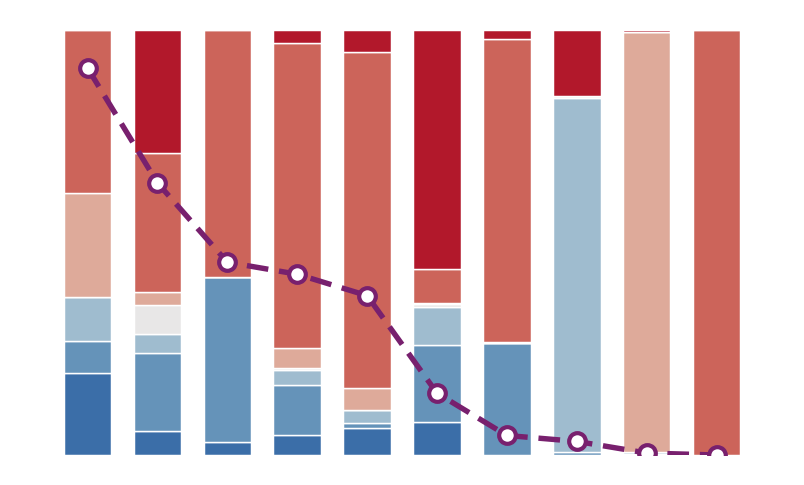

Saved figure:
./save_figs/fig4_d.svg


In [3]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-

"""
Fig. 4d plotting script

This version directly uses the prepared table `fig4_d.csv` as input.
It no longer reads recommendation CSVs, embedding .npy files, or prototype .pth files.

Required input table columns:
    Method
    Assignment quality
    P1 fraction_percent
    P2 fraction_percent
    ...
    P7 fraction_percent
"""

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap


# ============================================================
# 1. 文件路径
# ============================================================

# 直接把这个路径改成你的表格路径即可
INPUT_TABLE = r"./figs_data/fig4_d.csv"

FIG_DATA_DIR = r"./figs_data/"
FIG_SAVE_DIR = r"./save_figs/"

os.makedirs(FIG_DATA_DIR, exist_ok=True)
os.makedirs(FIG_SAVE_DIR, exist_ok=True)


# ============================================================
# 2. 画图参数
# ============================================================

# True：按照 Assignment quality 从高到低排序
# False：保持表格中的原始顺序
SORT_BY_ASSIGNMENT_QUALITY = True

# 是否保存透明背景 SVG
TRANSPARENT_BACKGROUND = True

# 原图尺寸：6.3 cm × 3.6 cm
FIG_WIDTH_CM = 6.3
FIG_HEIGHT_CM = 3.6

# Assignment quality 左轴范围
QUALITY_YLIM = (0, 0.65)

# stacked bar 右轴范围
FRACTION_YLIM = (0, 100)


# ============================================================
# 3. 基础函数
# ============================================================

def check_file_exists(path):
    if not os.path.exists(path):
        raise FileNotFoundError(f"找不到文件：{path}")


def load_plot_table(input_csv):
    """读取已经整理好的 Fig. 4d 画图数据表。"""
    check_file_exists(input_csv)

    df = pd.read_csv(input_csv)

    required_cols = ["Method", "Assignment quality"]
    for col in required_cols:
        if col not in df.columns:
            raise ValueError(
                f"输入表格缺少必要列：{col}\n"
                f"当前列名为：{list(df.columns)}"
            )

    fraction_cols = [
        c for c in df.columns
        if c.startswith("P") and c.endswith("fraction_percent")
    ]

    if len(fraction_cols) == 0:
        raise ValueError(
            "没有找到 prototype fraction 列。\n"
            "列名需要类似：P1 fraction_percent, P2 fraction_percent, ..."
        )

    # 按 P1, P2, ..., P7 的数字顺序排序，避免列顺序混乱
    fraction_cols = sorted(
        fraction_cols,
        key=lambda x: int(x.split()[0].replace("P", ""))
    )

    # 转成数值，避免字符串格式导致画图错误
    df["Assignment quality"] = pd.to_numeric(df["Assignment quality"], errors="coerce")
    for col in fraction_cols:
        df[col] = pd.to_numeric(df[col], errors="coerce")

    if df["Assignment quality"].isna().any():
        bad_rows = df[df["Assignment quality"].isna()].index.tolist()
        raise ValueError(f"Assignment quality 存在无法转换为数值的行：{bad_rows}")

    if df[fraction_cols].isna().any().any():
        raise ValueError("prototype fraction_percent 列中存在无法转换为数值的内容，请检查表格。")

    return df, fraction_cols


# ============================================================
# 4. 左轴 Assignment quality + 右轴 stacked bar
# ============================================================

def plot_vertical_stacked_assignment_quality(table_csv, out_dir, fig_data_dir):
    plot_df, fraction_cols = load_plot_table(table_csv)

    if SORT_BY_ASSIGNMENT_QUALITY:
        plot_df = plot_df.sort_values(
            by="Assignment quality",
            ascending=False
        ).reset_index(drop=True)
    else:
        plot_df = plot_df.reset_index(drop=True)

    method_order = plot_df["Method"].tolist()
    ratios_percent = plot_df[fraction_cols].values
    assignment_quality = plot_df["Assignment quality"].values

    # 如果输入表格中的比例不是百分比，而是 0-1 小数，则自动转换成百分比
    if np.nanmax(ratios_percent) <= 1.0:
        ratios_percent = ratios_percent * 100

    # 检查每行比例和是否接近 100，仅提醒，不中断程序
    row_sums = ratios_percent.sum(axis=1)
    if not np.allclose(row_sums, 100, atol=1.0):
        print("Warning: 部分方法的 P1-Pn fraction_percent 加和不接近 100%。")
        for method, value in zip(method_order, row_sums):
            print(f"  {method}: sum = {value:.3f}%")

    # =========================
    # 保存实际用于画图的数据
    # =========================
    plot_data_df = plot_df[["Method", "Assignment quality"]].copy()
    for i, col in enumerate(fraction_cols):
        plot_data_df[col] = ratios_percent[:, i]

    plot_data_csv = os.path.join(fig_data_dir, "fig4_d_from_table.csv")
    plot_data_df.to_csv(plot_data_csv, index=False)

    print("Saved plot data:")
    print(plot_data_csv)

    x = np.arange(len(method_order))
    num_prototypes = len(fraction_cols)

    # =========================
    # Nature red-blue colormap
    # =========================
    nature_rb_cmap = LinearSegmentedColormap.from_list(
        "nature_red_blue",
        [
            "#3B6EA8",  # muted blue
            "#7AA6C2",  # light blue
            "#E8E8E8",  # soft neutral
            "#D98B73",  # soft red-orange
            "#B2182B",  # deep red
        ],
    )

    if num_prototypes == 1:
        prototype_colors = [nature_rb_cmap(0.5)]
    else:
        prototype_colors = [
            nature_rb_cmap(i / (num_prototypes - 1))
            for i in range(num_prototypes)
        ]

    quality_color = "#78206E"

    plt.rcParams["font.family"] = "Arial"
    plt.rcParams["svg.fonttype"] = "none"
    plt.rcParams["pdf.fonttype"] = 42
    plt.rcParams["ps.fonttype"] = 42

    cm = 1 / 2.54
    fig, ax1 = plt.subplots(
        figsize=(FIG_WIDTH_CM * cm, FIG_HEIGHT_CM * cm),
        dpi=300
    )

    # =========================
    # 左轴：Assignment quality
    # =========================
    ax1.plot(
        x,
        assignment_quality,
        color=quality_color,
        marker="o",
        markersize=4.0,
        markerfacecolor="white",
        markeredgecolor=quality_color,
        markeredgewidth=1.0,
        linewidth=1.3,
        linestyle="--",
        dashes=(4, 2),
        zorder=10
    )

    ax1.set_ylim(*QUALITY_YLIM)

    # =========================
    # 右轴：Prototype assignment fraction
    # =========================
    ax2 = ax1.twinx()

    ax1.set_zorder(ax2.get_zorder() + 1)
    ax1.patch.set_visible(False)

    bottom = np.zeros(len(method_order))

    for i in range(num_prototypes):
        ax2.bar(
            x,
            ratios_percent[:, i],
            bottom=bottom,
            width=0.68,
            color=prototype_colors[i],
            edgecolor="white",
            linewidth=0.35,
            zorder=1
        )
        bottom += ratios_percent[:, i]

    ax2.set_ylim(*FRACTION_YLIM)

    # =========================
    # 删除所有数值、坐标轴、刻度、背景
    # 保持原代码中的无坐标轴风格，方便后期排版
    # =========================
    ax1.set_axis_off()
    ax2.set_axis_off()

    ax1.grid(False)
    ax2.grid(False)

    ax1.set_xticks([])
    ax1.set_yticks([])
    ax2.set_xticks([])
    ax2.set_yticks([])

    ax1.set_xlabel("")
    ax1.set_ylabel("")
    ax2.set_ylabel("")

    fig.patch.set_alpha(0)
    ax1.patch.set_alpha(0)
    ax2.patch.set_alpha(0)

    plt.subplots_adjust(
        left=0,
        right=1,
        bottom=0,
        top=1
    )

    # =========================
    # Save SVG
    # =========================
    svg_path = os.path.join(out_dir, "fig4_d.svg")

    plt.savefig(
        svg_path,
        format="svg",
        dpi=600,
        transparent=TRANSPARENT_BACKGROUND,
        bbox_inches="tight",
        pad_inches=0
    )

    plt.show()
    plt.close()

    print("Saved figure:")
    print(svg_path)


# ============================================================
# 5. 主程序
# ============================================================

def main():
    print("Loading plot table...")
    print(INPUT_TABLE)

    plot_vertical_stacked_assignment_quality(
        table_csv=INPUT_TABLE,
        out_dir=FIG_SAVE_DIR,
        fig_data_dir=FIG_DATA_DIR
    )


if __name__ == "__main__":
    main()


Loading full-model post-screened candidates...
Candidate dataframe shape: (78, 2)
Embedding shape: (78, 128)
Detected SMILES column: smiles
Loading learned prototype centroids...
Prototype centroids shape: (7, 128)

Top-4 candidates per valid prototype:
 prototype  molecule_rank  candidate_index  prototype_similarity                                                                                                                                          smiles
         1              1               11              0.821772                                                                                                                                        B(C)(C)C
         1              2               13              0.819822                                                                                                                                       B(C)(C)OC
         1              3               22              0.814349                                                       

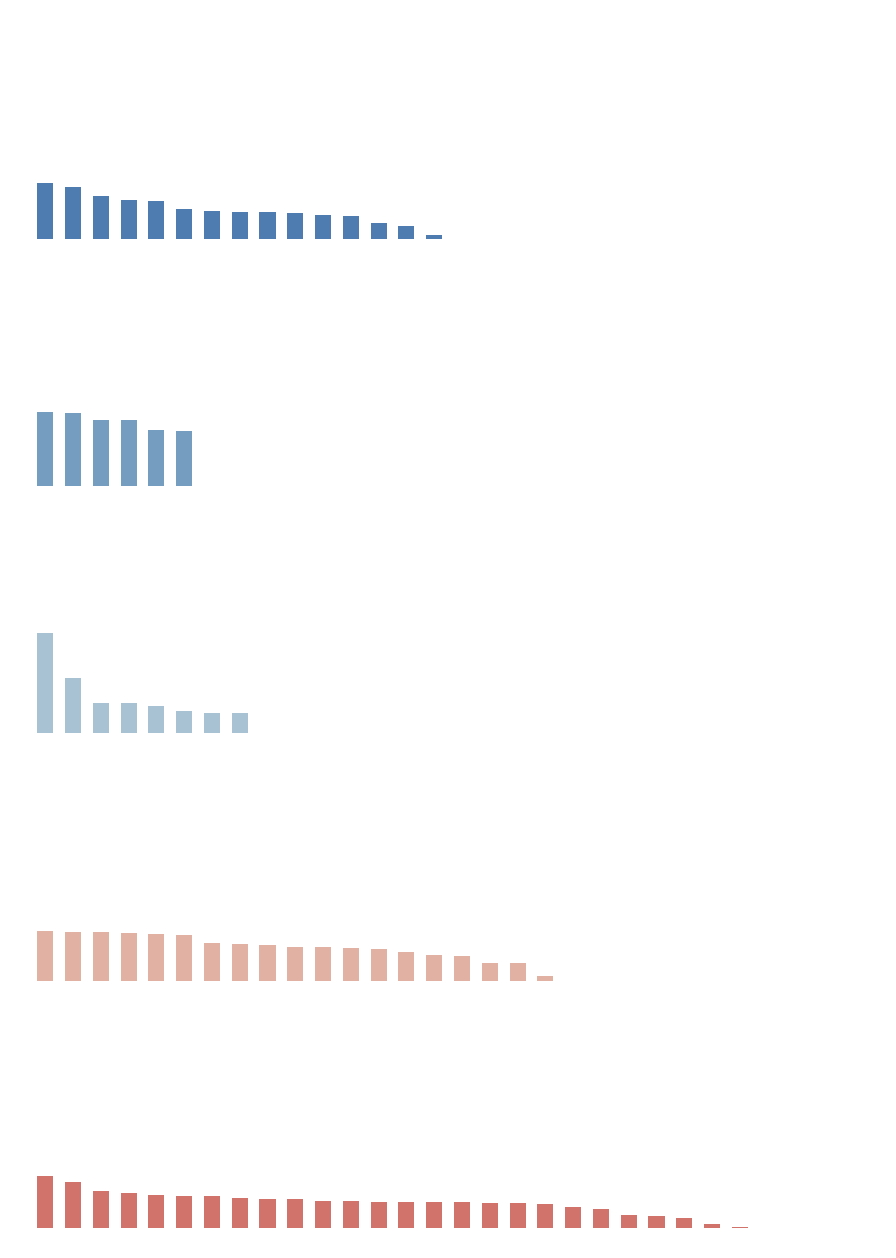

Saved figure:
./save_figs/fig4_e.svg

Saved top molecule SVGs:
./save_figs/fig4e_top_molecule_svgs
Saved SVG index:
./save_figs/fig4e_top_molecule_svgs/fig4_e.csv

Saved data:
./figs_data/fig4_e.csv
./figs_data/fig4_e.csv


In [6]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-

import os
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

from sklearn.preprocessing import normalize

from rdkit import Chem
from rdkit.Chem import AllChem
from rdkit.Chem.Draw import rdMolDraw2D


# ============================================================
# 1. 文件路径
# ============================================================

FULL_CSV = r"../outputs/recommendations_after_post_screening_full_model_ema_True_decor_True_topk_True_year_all.csv"
FULL_EMB = r"../outputs/embeddings_after_post_screening_full_model_ema_True_decor_True_topk_True_year_all.npy"
PROTO_EMB = r"../checkpoints_origin_backup/proto_centroids_GINE_epoch_300.pth"

FIG_DATA_DIR = r"./figs_data/"
FIG_SAVE_DIR = r"./save_figs/"

os.makedirs(FIG_DATA_DIR, exist_ok=True)
os.makedirs(FIG_SAVE_DIR, exist_ok=True)


# ============================================================
# 2. 全局画图风格
# ============================================================

plt.rcParams["font.family"] = "Arial"
plt.rcParams["svg.fonttype"] = "none"
plt.rcParams["pdf.fonttype"] = 42
plt.rcParams["ps.fonttype"] = 42


# ============================================================
# Nature red-blue colormap
# ============================================================

nature_rb_cmap = LinearSegmentedColormap.from_list(
    "nature_red_blue",
    [
        "#3B6EA8",  # muted blue
        "#7AA6C2",  # light blue
        "#E8E8E8",  # soft neutral
        "#D98B73",  # soft red-orange
        "#B2182B",  # deep red
    ],
)

PROTOTYPE_COLORS = [
    nature_rb_cmap(i / 6)
    for i in range(7)
]


CUSTOM_YLIMS = {
    1: (0.79, 0.91),
    2: (0.79, 0.91),
    3: (0.77, 0.91),
    4: (0.76, 0.86),
    5: (0.71, 0.88),
    6: (0.79, 0.91),
    7: (0.77, 0.87),
}


# ============================================================
# 3. 基础函数
# ============================================================

def check_file_exists(path):
    if not os.path.exists(path):
        raise FileNotFoundError(f"找不到文件：{path}")


def load_data(csv_path, emb_path):
    check_file_exists(csv_path)
    check_file_exists(emb_path)

    df = pd.read_csv(csv_path)
    emb = np.load(emb_path)

    if len(df) != emb.shape[0]:
        raise ValueError(
            "CSV行数和embedding数量不一致：\n"
            f"{csv_path}: {len(df)} rows\n"
            f"{emb_path}: {emb.shape[0]} embeddings"
        )

    return df, emb


def load_prototype_centroids(pth_path):
    check_file_exists(pth_path)

    obj = torch.load(pth_path, map_location="cpu")

    if isinstance(obj, torch.Tensor):
        centroids = obj

    elif isinstance(obj, dict):
        possible_keys = [
            "prototype_centroids",
            "prototypes",
            "centroids",
            "proto_centroids",
            "prototype_embeddings",
            "cluster_centers",
            "proto_centroids_GINE",
        ]

        found_key = None
        for key in possible_keys:
            if key in obj:
                found_key = key
                break

        if found_key is None:
            raise KeyError(
                f"在 {pth_path} 中没有找到 prototype centroids。\n"
                f"当前 pth 文件包含 keys：{list(obj.keys())}"
            )

        centroids = obj[found_key]

    else:
        raise TypeError(f"不支持的 pth 文件格式：{type(obj)}")

    if isinstance(centroids, torch.Tensor):
        centroids = centroids.detach().cpu().numpy()
    else:
        centroids = np.array(centroids)

    return centroids


def infer_smiles_col(df):
    possible_cols = [
        "smiles",
        "SMILES",
        "canonical_smiles",
        "Canonical_SMILES",
        "canonical_smiles_isomeric",
        "isosmiles",
        "Isomeric_SMILES",
    ]

    for col in possible_cols:
        if col in df.columns:
            return col

    return None


# ============================================================
# 4. 计算 prototype assignment 和 top-k similarity
# ============================================================

def compute_similarity_matrix(candidate_embeddings, prototype_centroids):
    candidate_embeddings = normalize(candidate_embeddings, axis=1)
    prototype_centroids = normalize(prototype_centroids, axis=1)
    return candidate_embeddings @ prototype_centroids.T


def select_top_candidates_per_prototype(df, embeddings, prototype_centroids, top_k=4):
    sim_matrix = compute_similarity_matrix(embeddings, prototype_centroids)

    assigned_proto = np.argmax(sim_matrix, axis=1)
    max_sim = np.max(sim_matrix, axis=1)

    num_prototypes = prototype_centroids.shape[0]

    detail_df = df.copy()
    detail_df["candidate_index"] = np.arange(len(detail_df))
    detail_df["assigned_prototype"] = assigned_proto + 1
    detail_df["max_prototype_similarity"] = max_sim

    result_rows = []

    for p in range(num_prototypes):
        proto_id = p + 1

        sub = detail_df[detail_df["assigned_prototype"] == proto_id].copy()

        if len(sub) == 0:
            continue

        sub["prototype_similarity"] = sim_matrix[sub.index.values, p]
        sub = sub.sort_values("prototype_similarity", ascending=False).head(top_k)

        for rank, (idx, row) in enumerate(sub.iterrows(), start=1):
            out = row.to_dict()
            out["prototype"] = proto_id
            out["molecule_rank"] = rank
            out["x_label"] = f"M{rank}"
            result_rows.append(out)

    top_df = pd.DataFrame(result_rows)
    return top_df, detail_df


# ============================================================
# 5. 作图
# ============================================================

def plot_top4_similarity_by_prototype(top_df, out_dir, top_k=4):
    if top_df.empty:
        raise ValueError("top_df为空：没有任何 prototype 具有 candidate，无法作图。")

    valid_prototypes = sorted(top_df["prototype"].dropna().astype(int).unique())
    n_proto = len(valid_prototypes)

    cm = 1 / 2.54

    fig, axes = plt.subplots(
        n_proto,
        1,
        figsize=(7.08 * cm, 10.15 * cm),
        dpi=300,
        sharex=True,
        sharey=False,
    )

    if n_proto == 1:
        axes = np.array([axes])

    sim_values = top_df["prototype_similarity"].dropna().values
    y_min = max(0.0, np.floor((sim_values.min() - 0.03) * 100) / 100)
    y_max = min(1.0, np.ceil((sim_values.max() + 0.03) * 100) / 100)

    if y_max - y_min < 0.08:
        mid = (y_max + y_min) / 2
        y_min = max(0.0, mid - 0.04)
        y_max = min(1.0, mid + 0.04)

    plot_rows = []

    for proto_id in valid_prototypes:
        proto_rows = top_df[top_df["prototype"] == proto_id].copy()
        proto_rows = proto_rows.sort_values("molecule_rank")

        for _, row in proto_rows.iterrows():
            plot_rows.append({
                "prototype": int(proto_id),
                "molecule_rank": int(row["molecule_rank"]),
                "x": int(row["molecule_rank"]),
                "x_label": f"M{int(row['molecule_rank'])}",
                "prototype_similarity": float(row["prototype_similarity"]),
                "candidate_index": int(row["candidate_index"]),
            })

    plot_data_df = pd.DataFrame(plot_rows)

    plot_data_csv = os.path.join(
        FIG_DATA_DIR,
        "fig4_e.csv"
    )
    plot_data_df.to_csv(plot_data_csv, index=False)

    print("Saved plot data:")
    print(plot_data_csv)

    for ax, proto_id in zip(axes, valid_prototypes):
        proto_rows = top_df[top_df["prototype"] == proto_id].copy()
        proto_rows = proto_rows.sort_values("molecule_rank")

        color = PROTOTYPE_COLORS[(proto_id - 1) % len(PROTOTYPE_COLORS)]

        x = proto_rows["molecule_rank"].values.astype(int)
        y = proto_rows["prototype_similarity"].values.astype(float)

        ax.bar(
            x,
            y,
            width=0.58,
            color=color,
            alpha=0.90,
            edgecolor="none",
            linewidth=0,
            zorder=3,
        )

        local_y_min, local_y_max = CUSTOM_YLIMS.get(proto_id, (y_min, y_max))

        ax.set_ylim(local_y_min, local_y_max)
        ax.set_xlim(0.45, top_k + 0.55)

        # 删除所有数值、坐标轴、刻度、背景
        ax.set_axis_off()
        ax.grid(False)

        ax.set_xticks([])
        ax.set_yticks([])
        ax.set_xlabel("")
        ax.set_ylabel("")

        for spine in ax.spines.values():
            spine.set_visible(False)

        ax.patch.set_alpha(0)

    fig.patch.set_alpha(0)

    plt.subplots_adjust(
        left=0,
        right=1,
        top=1,
        bottom=0,
        hspace=0.18,
    )

    svg_path = os.path.join(
        out_dir,
        "fig4_e.svg"
    )

    plt.savefig(
        svg_path,
        format="svg",
        dpi=600,
        transparent=True,
        bbox_inches="tight",
        pad_inches=0
    )

    plt.show()
    plt.close()

    print("Saved figure:")
    print(svg_path)


# ============================================================
# 6. 保存每个 prototype 的 top-4 分子结构 SVG
# ============================================================

def save_top_molecule_svgs(top_df, smiles_col, out_dir, top_k=4):
    if smiles_col is None or smiles_col not in top_df.columns:
        raise ValueError(
            "需要保存分子 SVG，但没有找到 SMILES 列。\n"
            "请检查 CSV 中是否包含 smiles / SMILES / canonical_smiles 等列名。"
        )

    svg_dir = os.path.join(out_dir, "fig4e_top_molecule_svgs")
    os.makedirs(svg_dir, exist_ok=True)

    saved_rows = []

    valid_prototypes = sorted(top_df["prototype"].dropna().astype(int).unique())

    for proto_id in valid_prototypes:
        proto_rows = top_df[top_df["prototype"] == proto_id].copy()
        proto_rows = proto_rows.sort_values("molecule_rank").head(top_k)

        color = PROTOTYPE_COLORS[(proto_id - 1) % len(PROTOTYPE_COLORS)]

        for _, row in proto_rows.iterrows():
            smi = row.get(smiles_col, np.nan)

            if pd.isna(smi):
                continue

            smi = str(smi)
            mol = Chem.MolFromSmiles(smi)

            if mol is None:
                print(f"Warning: invalid SMILES skipped: P{proto_id}, {smi}")
                continue

            try:
                AllChem.Compute2DCoords(mol)
            except Exception:
                pass

            rank = int(row["molecule_rank"])
            sim = float(row["prototype_similarity"])
            cand_idx = int(row["candidate_index"]) if pd.notna(row.get("candidate_index", np.nan)) else -1

            file_name = f"P{proto_id}_M{rank}_sim_{sim:.3f}_idx_{cand_idx}.svg"
            svg_path = os.path.join(svg_dir, file_name)

            drawer = rdMolDraw2D.MolDraw2DSVG(320, 240)
            opts = drawer.drawOptions()
            opts.clearBackground = False
            opts.bondLineWidth = 2.0
            opts.minFontSize = 12
            opts.maxFontSize = 18
            opts.padding = 0.08

            drawer.DrawMolecule(mol)
            drawer.FinishDrawing()

            svg = drawer.GetDrawingText()

            with open(svg_path, "w", encoding="utf-8") as f:
                f.write(svg)

            saved_rows.append({
                "prototype": proto_id,
                "molecule_rank": rank,
                "candidate_index": cand_idx,
                "prototype_similarity": sim,
                smiles_col: smi,
                "svg_path": svg_path,
                "svg_file": file_name,
            })

    saved_df = pd.DataFrame(saved_rows)
    svg_index_csv = os.path.join(svg_dir, "fig4_e.csv")
    saved_df.to_csv(svg_index_csv, index=False)

    print("\nSaved top molecule SVGs:")
    print(svg_dir)
    print("Saved SVG index:")
    print(svg_index_csv)

    return saved_df


# ============================================================
# 7. 主程序
# ============================================================

def main():
    print("Loading full-model post-screened candidates...")
    df, embeddings = load_data(FULL_CSV, FULL_EMB)
    print("Candidate dataframe shape:", df.shape)
    print("Embedding shape:", embeddings.shape)

    smiles_col = infer_smiles_col(df)

    if smiles_col is not None:
        print("Detected SMILES column:", smiles_col)
    else:
        raise ValueError("需要保存分子SVG图片，但CSV中没有检测到SMILES列。请检查列名。")

    print("Loading learned prototype centroids...")
    prototype_centroids = load_prototype_centroids(PROTO_EMB)
    print("Prototype centroids shape:", prototype_centroids.shape)

    if embeddings.shape[1] != prototype_centroids.shape[1]:
        raise ValueError(
            "candidate embedding维度和prototype维度不一致："
            f"{embeddings.shape[1]} vs {prototype_centroids.shape[1]}"
        )

    top_k = 30

    top_df, detail_df = select_top_candidates_per_prototype(
        df=df,
        embeddings=embeddings,
        prototype_centroids=prototype_centroids,
        top_k=top_k,
    )

    top_csv = os.path.join(FIG_DATA_DIR, "fig4_e.csv")
    detail_csv = os.path.join(FIG_DATA_DIR, "fig4_e.csv")

    top_df.to_csv(top_csv, index=False)
    detail_df.to_csv(detail_csv, index=False)

    print("\nTop-4 candidates per valid prototype:")
    show_cols = ["prototype", "molecule_rank", "candidate_index", "prototype_similarity"]

    if smiles_col is not None and smiles_col in top_df.columns:
        show_cols.append(smiles_col)

    print(top_df[show_cols].to_string(index=False))

    plot_top4_similarity_by_prototype(
        top_df=top_df,
        out_dir=FIG_SAVE_DIR,
        top_k=top_k,
    )

    save_top_molecule_svgs(
        top_df=top_df,
        smiles_col=smiles_col,
        out_dir=FIG_SAVE_DIR,
        top_k=top_k,
    )

    print("\nSaved data:")
    print(top_csv)
    print(detail_csv)


if __name__ == "__main__":
    main()

Prototype centroids: (7, 128)
Known additives loaded: 126 valid, 0 invalid
Evaluating Full model...
Evaluating w/o EMA...
Evaluating w/o top-K...
Evaluating w/o decorrelation...
Saved heatmap plot data:
./figs_data/fig4_f.csv


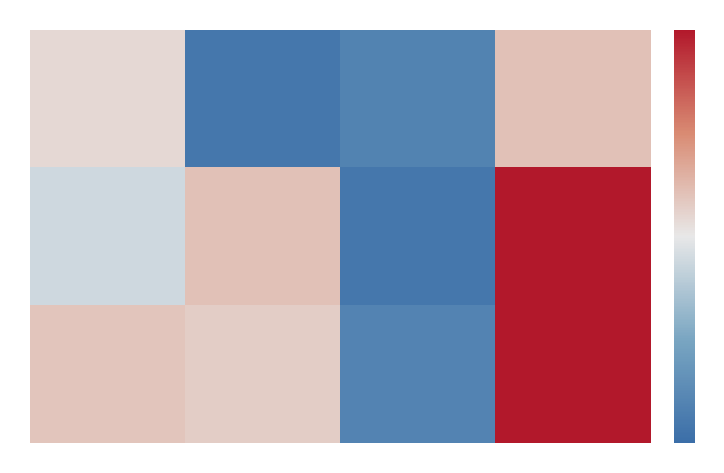

Saved figure:
./save_figs/fig4_f.svg


In [10]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-

import os
import json
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

from sklearn.preprocessing import normalize
from sklearn.metrics import silhouette_score

from rdkit import Chem
from rdkit.Chem import rdFingerprintGenerator
from rdkit import DataStructs


# ============================================================
# 1. Paths
# ============================================================

OUT_DIR = r"./save_figs/"
DATA_DIR = r"./figs_data/"
os.makedirs(OUT_DIR, exist_ok=True)
os.makedirs(DATA_DIR, exist_ok=True)

PROTO_EMB = r"../checkpoints_origin_backup/proto_centroids_GINE_epoch_300.pth"
KNOWN_ADDITIVE_JSON = r"../data/additives.json"
SMILES_COL = "smiles"
BEFORE_N = 30800

METHODS = {
    "Full model": {
        "csv": r"../outputs/recommendations_after_post_screening_full_model_ema_True_decor_True_topk_True.csv",
        "emb": r"../outputs/embeddings_after_post_screening_full_model_ema_True_decor_True_topk_True.npy",
    },
    "w/o EMA": {
        "csv": r"../outputs/recommendations_after_post_screening_full_model_ema_False_decor_True_topk_True.csv",
        "emb": r"../outputs/embeddings_after_post_screening_full_model_ema_False_decor_True_topk_True.npy",
    },
    "w/o top-K": {
        "csv": r"../outputs/recommendations_after_post_screening_full_model_ema_True_decor_True_topk_False.csv",
        "emb": r"../outputs/embeddings_after_post_screening_full_model_ema_True_decor_True_topk_False.npy",
    },
    "w/o decorrelation": {
        "csv": r"../outputs/recommendations_after_post_screening_full_model_ema_True_decor_False_topk_True.csv",
        "emb": r"../outputs/embeddings_after_post_screening_full_model_ema_True_decor_False_topk_True.npy",
    },
}

ABLATION_METHODS = [
    "w/o EMA",
    "w/o top-K",
    "w/o decorrelation",
]


# ============================================================
# 2. Style
# ============================================================

plt.rcParams["font.family"] = "Arial"
plt.rcParams["svg.fonttype"] = "none"
plt.rcParams["pdf.fonttype"] = 42
plt.rcParams["ps.fonttype"] = 42


# ============================================================
# 3. Basic utilities
# ============================================================

def check_file(path):
    if not os.path.exists(path):
        raise FileNotFoundError(f"File not found: {path}")


def load_csv_emb(csv_path, emb_path):
    check_file(csv_path)
    check_file(emb_path)

    df = pd.read_csv(csv_path)
    emb = np.load(emb_path)

    if len(df) != emb.shape[0]:
        raise ValueError(
            f"CSV rows != embeddings: {len(df)} vs {emb.shape[0]}"
        )

    return df, emb


def load_prototypes(path):
    check_file(path)
    obj = torch.load(path, map_location="cpu")

    if isinstance(obj, torch.Tensor):
        proto = obj.detach().cpu().numpy()

    elif isinstance(obj, dict):
        possible_keys = [
            "prototype_centroids",
            "prototypes",
            "centroids",
            "proto_centroids",
            "prototype_embeddings",
            "cluster_centers",
            "proto_centroids_GINE",
        ]

        hit = next((k for k in possible_keys if k in obj), None)

        if hit is None:
            raise KeyError(
                f"Cannot find prototype centroids. Available keys: {list(obj.keys())}"
            )

        proto = obj[hit]

        if isinstance(proto, torch.Tensor):
            proto = proto.detach().cpu().numpy()
        else:
            proto = np.asarray(proto)

    else:
        raise TypeError(f"Unsupported prototype file type: {type(obj)}")

    if proto.ndim != 2:
        raise ValueError(f"Prototype centroids should be 2D, got {proto.shape}")

    return proto


def get_morgan_generator(radius=2, fp_size=2048):
    return rdFingerprintGenerator.GetMorganGenerator(
        radius=radius,
        fpSize=fp_size,
    )


def compute_morgan_fps(smiles_list, radius=2, fp_size=2048):
    generator = get_morgan_generator(radius=radius, fp_size=fp_size)

    fps = []
    valid_smiles = []
    invalid_smiles = []

    for smi in smiles_list:
        smi = str(smi)
        mol = Chem.MolFromSmiles(smi)

        if mol is None:
            fps.append(None)
            invalid_smiles.append(smi)
        else:
            fps.append(generator.GetFingerprint(mol))
            valid_smiles.append(smi)

    return fps, valid_smiles, invalid_smiles


def load_known_additives_from_json(json_path):
    check_file(json_path)

    with open(json_path, "r", encoding="utf-8") as f:
        data = json.load(f)

    smiles_list = []
    for _, info in data.items():
        if isinstance(info, dict) and info.get("smiles", None) is not None:
            smiles_list.append(info["smiles"])

    if len(smiles_list) == 0:
        raise ValueError(f"No known additive SMILES found in {json_path}")

    fps, valid_smiles, invalid_smiles = compute_morgan_fps(smiles_list)
    known_fps = [fp for fp in fps if fp is not None]

    if len(known_fps) == 0:
        raise ValueError("No valid known additive fingerprints.")

    print(f"Known additives loaded: {len(known_fps)} valid, {len(invalid_smiles)} invalid")
    return known_fps


# ============================================================
# 4. Metric calculation
# ============================================================

def prototype_metrics(emb, proto):
    z = normalize(emb, axis=1)
    c = normalize(proto, axis=1)
    sim = z @ c.T

    assigned = np.argmax(sim, axis=1)
    max_sim = np.max(sim, axis=1)
    n_proto = proto.shape[0]

    coverage = len(np.unique(assigned)) / n_proto

    counts = np.bincount(assigned, minlength=n_proto)
    probs = counts / counts.sum()
    probs_nonzero = probs[probs > 0]

    if len(probs_nonzero) == 0:
        entropy = np.nan
    else:
        entropy = -np.sum(probs_nonzero * np.log(probs_nonzero)) / np.log(n_proto)

    unique_labels = np.unique(assigned)

    if len(unique_labels) < 2 or len(unique_labels) >= len(assigned):
        sil = np.nan
    else:
        sil = silhouette_score(z, assigned, metric="cosine")

    return {
        "Prototype similarity": float(np.mean(max_sim)),
        "Prototype coverage": float(coverage),
        "Assignment entropy": float(entropy),
        "Silhouette": float(sil) if not np.isnan(sil) else np.nan,
    }


def candidate_diversity(smiles_list, radius=2, fp_size=2048):
    fps, valid_smiles, invalid_smiles = compute_morgan_fps(
        smiles_list,
        radius=radius,
        fp_size=fp_size,
    )

    fps = [fp for fp in fps if fp is not None]

    if len(fps) < 2:
        return np.nan

    sims = []

    for i in range(len(fps)):
        for j in range(i + 1, len(fps)):
            sims.append(DataStructs.TanimotoSimilarity(fps[i], fps[j]))

    return float(1.0 - np.mean(sims))


def known_additive_metrics(smiles_list, known_fps):
    candidate_fps, valid_smiles, invalid_smiles = compute_morgan_fps(smiles_list)

    max_sims = []

    for fp in candidate_fps:
        if fp is None:
            max_sims.append(np.nan)
            continue

        sims = DataStructs.BulkTanimotoSimilarity(fp, known_fps)
        max_sims.append(float(np.max(sims)))

    max_sims = np.asarray(max_sims, dtype=float)
    valid = max_sims[~np.isnan(max_sims)]

    if len(valid) == 0:
        return {
            "Known-additive similarity": np.nan,
            "Novelty score": np.nan,
            "High similarity ratio >0.75": np.nan,
            "Moderate similarity ratio 0.40-0.75": np.nan,
            "Low similarity ratio <0.40": np.nan,
        }

    return {
        "Known-additive similarity": float(np.mean(valid)),
        "Novelty score": float(np.mean(1.0 - valid)),
        "High similarity ratio >0.75": float(np.mean(valid > 0.75)),
        "Moderate similarity ratio 0.40-0.75": float(
            np.mean((valid >= 0.40) & (valid <= 0.75))
        ),
        "Low similarity ratio <0.40": float(np.mean(valid < 0.40)),
    }


def evaluate_method(method_name, csv_path, emb_path, proto, known_fps):
    df, emb = load_csv_emb(csv_path, emb_path)

    if emb.shape[1] != proto.shape[1]:
        raise ValueError(
            f"{method_name}: embedding dim != prototype dim: "
            f"{emb.shape[1]} vs {proto.shape[1]}"
        )

    if SMILES_COL not in df.columns:
        raise ValueError(
            f"{method_name}: cannot find SMILES column '{SMILES_COL}'"
        )

    smiles_list = df[SMILES_COL].astype(str).tolist()

    metrics = prototype_metrics(emb, proto)
    metrics.update(known_additive_metrics(smiles_list, known_fps))
    metrics["Candidate diversity"] = candidate_diversity(smiles_list)
    metrics["Post-screening survival"] = len(df) / BEFORE_N

    metrics["Method"] = method_name
    metrics["After screening number"] = len(df)

    return metrics


# ============================================================
# 5. Build damage heatmap data
# ============================================================

def build_damage_heatmap_data(raw_df):
    metrics = [
        "Prototype similarity",
        "Assignment entropy",
        "High similarity ratio >0.75",
        "Silhouette",
    ]

    full_row = raw_df[raw_df["Method"] == "Full model"]

    if len(full_row) != 1:
        raise ValueError("raw_df must contain exactly one row named 'Full model'.")

    full_values = full_row.iloc[0][metrics].astype(float)

    damage_raw = pd.DataFrame(index=ABLATION_METHODS, columns=metrics, dtype=float)
    failed_mask = pd.DataFrame(False, index=ABLATION_METHODS, columns=metrics)

    for method in ABLATION_METHODS:
        row = raw_df[raw_df["Method"] == method]

        if len(row) != 1:
            raise ValueError(f"raw_df must contain exactly one row named '{method}'.")

        row_values = row.iloc[0][metrics].astype(float)

        for metric in metrics:
            ablated_value = row_values[metric]
            full_value = full_values[metric]

            if pd.isna(ablated_value) or pd.isna(full_value):
                damage_raw.loc[method, metric] = np.nan
                failed_mask.loc[method, metric] = True
            else:
                damage_raw.loc[method, metric] = full_value - ablated_value

    damage_for_norm = damage_raw.copy()
    damage_for_norm = damage_for_norm.clip(lower=0)

    all_values = damage_for_norm.values.astype(float)
    valid_values = all_values[~np.isnan(all_values)]

    damage_norm = damage_for_norm.copy()

    if len(valid_values) == 0:
        damage_norm.iloc[:, :] = 1.0
    else:
        global_max_damage = np.nanmax(valid_values)

        if np.isclose(global_max_damage, 0):
            damage_norm.iloc[:, :] = 0.0
        else:
            damage_norm = damage_norm / global_max_damage

    damage_norm = damage_norm.fillna(1.0)

    return damage_raw, damage_norm, failed_mask, metrics


# ============================================================
# 6. Plot heatmap
# ============================================================

def plot_component_damage_heatmap(
    damage_raw,
    damage_norm,
    failed_mask,
    metrics,
    out_dir,
):
    row_labels = [
        "w/o EMA",
        "w/o top-K",
        "w/o decorrelation",
    ]

    matrix = damage_norm.loc[row_labels, metrics].values.astype(float)

    plot_data_df = damage_norm.loc[row_labels, metrics].copy()
    plot_data_df.index.name = "Removed component"

    plot_data_csv = os.path.join(DATA_DIR, "fig4_f.csv")
    plot_data_df.to_csv(plot_data_csv)

    print("Saved heatmap plot data:")
    print(plot_data_csv)

    nature_rb_cmap = LinearSegmentedColormap.from_list(
        "nature_red_blue",
        [
            "#3B6EA8",
            "#7AA6C2",
            "#E8E8E8",
            "#D98B73",
            "#B2182B",
        ],
    )

    cm = 1 / 2.54

    fig, ax = plt.subplots(
        figsize=(5.71 * cm, 3.5 * cm),
        dpi=300
    )

    im = ax.imshow(
        matrix,
        cmap=nature_rb_cmap,
        vmin=0,
        vmax=1,
        aspect="auto",
    )

    # colorbar：保留，但删除数值、刻度、边框
    cbar = plt.colorbar(
        im,
        ax=ax,
        fraction=0.045,
        pad=0.035,
    )

    cbar.set_ticks([])
    cbar.ax.tick_params(length=0)
    cbar.outline.set_visible(False)

    for spine in cbar.ax.spines.values():
        spine.set_visible(False)

    # 删除 heatmap 坐标轴、刻度、背景
    ax.set_axis_off()
    ax.grid(False)

    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_xlabel("")
    ax.set_ylabel("")

    for spine in ax.spines.values():
        spine.set_visible(False)

    fig.patch.set_alpha(0)
    ax.patch.set_alpha(0)
    cbar.ax.patch.set_alpha(0)

    plt.subplots_adjust(
        left=0,
        right=1,
        bottom=0,
        top=1
    )

    svg_path = os.path.join(
        out_dir,
        "fig4_f.svg"
    )

    plt.savefig(
        svg_path,
        format="svg",
        dpi=600,
        transparent=True,
        bbox_inches="tight",
        pad_inches=0
    )

    plt.show()
    plt.close()

    print("Saved figure:")
    print(svg_path)


# ============================================================
# 7. Main
# ============================================================

def main():
    proto = load_prototypes(PROTO_EMB)
    print("Prototype centroids:", proto.shape)

    known_fps = load_known_additives_from_json(KNOWN_ADDITIVE_JSON)

    rows = []

    for method_name, info in METHODS.items():
        print(f"Evaluating {method_name}...")
        rows.append(
            evaluate_method(
                method_name=method_name,
                csv_path=info["csv"],
                emb_path=info["emb"],
                proto=proto,
                known_fps=known_fps,
            )
        )

    raw_df = pd.DataFrame(rows)

    raw_df = raw_df[
        [
            "Method",
            "Prototype similarity",
            "Prototype coverage",
            "Assignment entropy",
            "Known-additive similarity",
            "High similarity ratio >0.75",
            "Candidate diversity",
            "Silhouette",
        ]
    ]

    damage_raw, damage_norm, failed_mask, metrics = build_damage_heatmap_data(raw_df)

    plot_component_damage_heatmap(
        damage_raw=damage_raw,
        damage_norm=damage_norm,
        failed_mask=failed_mask,
        metrics=metrics,
        out_dir=OUT_DIR,
    )


if __name__ == "__main__":
    main()

In [26]:
# -*- coding: utf-8 -*-

import os
import numpy as np
import pandas as pd
from rdkit import Chem


# =========================================================
# 0. Paths
# =========================================================
SEARCHING_SPACE_CSV = "../data/searching_space_data_V2.csv"
RECOMMENDED_CSV = "../result_files_origin_backup/predicted_labels.csv"

OLD_PROTO_FREQ_CSV = "./figs_data/fig3_e.csv"

OUT_DIR = "./prototype_motif_retention_sankey_only"
os.makedirs(OUT_DIR, exist_ok=True)


# =========================================================
# 1. Helper functions
# =========================================================
def normalize_np_label(x):
    s = str(x).strip()
    if s.startswith("NP"):
        return s
    digits = "".join([c for c in s if c.isdigit()])
    if digits == "":
        return s
    return f"NP{int(digits)}"


def smiles_to_mol(smiles):
    if pd.isna(smiles):
        return None
    try:
        return Chem.MolFromSmiles(str(smiles))
    except Exception:
        return None


def has_substructure(mol, patt):
    if mol is None or patt is None:
        return False
    try:
        return mol.HasSubstructMatch(patt)
    except Exception:
        return False


def sort_np_labels(labels):
    return sorted(
        labels,
        key=lambda x: int("".join([c for c in str(x) if c.isdigit()]) or 999)
    )


def sort_proto_labels(labels):
    return sorted(
        labels,
        key=lambda x: int("".join([c for c in str(x) if c.isdigit()]) or 999)
    )


# =========================================================
# 2. Load old prototype motif frequency table
# =========================================================
freq_df = pd.read_csv(OLD_PROTO_FREQ_CSV)

required_freq_cols = [
    "prototype",
    "motif",
    "smarts",
    "n_molecules_in_prototype",
    "motif_count",
    "motif_frequency",
]

for col in required_freq_cols:
    if col not in freq_df.columns:
        raise ValueError(f"OLD_PROTO_FREQ_CSV 缺少必要列: {col}")

freq_df["prototype"] = freq_df["prototype"].astype(str)
freq_df["motif"] = freq_df["motif"].astype(str)
freq_df["motif_frequency"] = freq_df["motif_frequency"].astype(float)

SMARTS_PATTERNS = (
    freq_df[["motif", "smarts"]]
    .drop_duplicates(subset=["motif"])
    .set_index("motif")["smarts"]
    .to_dict()
)

motif_names = list(SMARTS_PATTERNS.keys())
old_protos = sort_proto_labels(freq_df["prototype"].unique())

print("\nOld prototypes:", old_protos)
print("Motifs:", motif_names)

OLD_PROTO_MOTIF_WEIGHTS = {}

for old_p in old_protos:
    sub = freq_df[freq_df["prototype"] == old_p].copy()

    weight_dict = {}
    for _, row in sub.iterrows():
        motif = row["motif"]
        weight = float(row["motif_frequency"])

        if weight > 0:
            weight_dict[motif] = weight

    if len(weight_dict) == 0:
        raise ValueError(f"{old_p} 没有任何 motif_frequency > 0 的共享骨架")

    OLD_PROTO_MOTIF_WEIGHTS[old_p] = weight_dict


# =========================================================
# 3. Load recommendation data
# =========================================================
search_df = pd.read_csv(SEARCHING_SPACE_CSV)
rec_df = pd.read_csv(RECOMMENDED_CSV)

required_search_cols = ["cid", "SMILES"]
required_rec_cols = ["id", "label"]

for col in required_search_cols:
    if col not in search_df.columns:
        raise ValueError(f"searching_space_data_V2.csv 缺少必要列: {col}")

for col in required_rec_cols:
    if col not in rec_df.columns:
        raise ValueError(f"recommended file 缺少必要列: {col}")

search_df["cid"] = search_df["cid"].astype(str)
rec_df["id"] = rec_df["id"].astype(str)

rec_df["NP"] = rec_df["label"].apply(normalize_np_label)

candidate_cols = ["cid", "SMILES"]
for optional_col in ["formula", "weight", "heavy_atom"]:
    if optional_col in search_df.columns:
        candidate_cols.append(optional_col)

merged = rec_df.merge(
    search_df[candidate_cols],
    left_on="id",
    right_on="cid",
    how="left"
)

missing_smiles = merged["SMILES"].isna().sum()
print("\nMissing SMILES after merge:", missing_smiles)

if missing_smiles > 0:
    print("\nWarning: 以下推荐分子没有在 searching_space_data_V2.csv 中找到:")
    print(merged.loc[merged["SMILES"].isna(), ["id", "label"]].head(20))

print("\nNP counts:")
print(merged["NP"].value_counts().sort_index())


# =========================================================
# 4. Compile SMARTS
# =========================================================
compiled_patterns = {}

for motif_name, smarts in SMARTS_PATTERNS.items():
    patt = Chem.MolFromSmarts(smarts)
    if patt is None:
        raise ValueError(f"Invalid SMARTS: {motif_name} -> {smarts}")
    compiled_patterns[motif_name] = patt

print("\nAll SMARTS patterns compiled successfully.")


# =========================================================
# 5. SMARTS matching
# =========================================================
merged["mol"] = merged["SMILES"].apply(smiles_to_mol)
merged["valid_mol"] = merged["mol"].apply(lambda x: x is not None)

print("\nInvalid molecule number:", (~merged["valid_mol"]).sum())

for motif_name, patt in compiled_patterns.items():
    merged[f"hit__{motif_name}"] = merged["mol"].apply(
        lambda mol: has_substructure(mol, patt)
    )


# =========================================================
# 6. Frequency-weighted old prototype contribution score
# =========================================================
for old_p, weight_dict in OLD_PROTO_MOTIF_WEIGHTS.items():
    denom = sum(weight_dict.values())

    score = np.zeros(len(merged), dtype=float)

    for motif, weight in weight_dict.items():
        hit_col = f"hit__{motif}"
        hit_arr = merged[hit_col].astype(float).values
        score += hit_arr * weight

    score = score / denom

    merged[f"weighted_score_percent__{old_p}"] = score * 100


old_proto_score_cols = [f"weighted_score_percent__{p}" for p in old_protos]

merged["max_weighted_old_proto_score_percent"] = merged[old_proto_score_cols].max(axis=1)
merged["best_matched_old_proto"] = merged[old_proto_score_cols].idxmax(axis=1)
merged["best_matched_old_proto"] = merged["best_matched_old_proto"].str.replace(
    "weighted_score_percent__", "", regex=False
)

merged.drop(columns=["mol"]).to_csv(
    os.path.join(OUT_DIR, "recommended_molecules_weighted_old_proto_scores.csv"),
    index=False
)


# =========================================================
# 7. NP × old prototype weighted retention matrix
# =========================================================
new_protos = sort_np_labels(merged["NP"].dropna().unique())

weighted_retention_df = pd.DataFrame(
    0.0,
    index=new_protos,
    columns=old_protos
)

for np_id in new_protos:
    sub = merged[merged["NP"] == np_id]

    for old_p in old_protos:
        score_col = f"weighted_score_percent__{old_p}"
        weighted_retention_df.loc[np_id, old_p] = sub[score_col].mean()


weighted_retention_df.to_csv(
    os.path.join(OUT_DIR, "NP_old_prototype_frequency_weighted_retention_percent.csv")
)

print("\nFrequency-weighted retention score matrix (%):")
print(weighted_retention_df.round(2))


# =========================================================
# 8. Clean Sankey using matplotlib
#    - no text
#    - no axis
#    - no background
#    - transparent SVG
#    - gradient links
#    - only figure content is saved
# =========================================================
import matplotlib.pyplot as plt
from matplotlib.path import Path
from matplotlib.patches import PathPatch, Rectangle
from matplotlib.colors import to_rgb


plt.rcParams["svg.fonttype"] = "none"
plt.rcParams["pdf.fonttype"] = 42
plt.rcParams["ps.fonttype"] = 42


FLOW_THRESHOLD = 2.0
flow_df = weighted_retention_df.copy()

old_nodes = list(flow_df.columns)
new_nodes = list(flow_df.index)

old_colors = [
    "#3B6EA8", "#4F82B3", "#6396BD", "#7AA6C2",
    "#9FBFD0", "#C9DCEE", "#DAE4EC"
]

new_colors = [
    "#F0D4C8", "#E7C1B0", "#D98B73", "#CC6E5F",
    "#B2182B", "#8F1225", "#6F0F1D"
]


def interpolate_color(c1, c2, t, alpha=0.42):
    r1, g1, b1 = to_rgb(c1)
    r2, g2, b2 = to_rgb(c2)

    r = r1 * (1 - t) + r2 * t
    g = g1 * (1 - t) + g2 * t
    b = b1 * (1 - t) + b2 * t

    return (r, g, b, alpha)


flows = []

for old_i, old_p in enumerate(old_nodes):
    for new_j, np_id in enumerate(new_nodes):
        val = float(flow_df.loc[np_id, old_p])

        if val >= FLOW_THRESHOLD:
            flows.append({
                "old": old_p,
                "new": np_id,
                "old_i": old_i,
                "new_j": new_j,
                "value": val,
            })


old_total = {p: 0.0 for p in old_nodes}
new_total = {p: 0.0 for p in new_nodes}

for f in flows:
    old_total[f["old"]] += f["value"]
    new_total[f["new"]] += f["value"]

total_flow = sum(f["value"] for f in flows)

if total_flow == 0:
    raise ValueError("No valid flows found. Please lower FLOW_THRESHOLD.")


# =========================================================
# Figure size
# width 7.08 cm, height 3.86 cm
# =========================================================
cm = 1 / 2.54

fig, ax = plt.subplots(
    figsize=(7.08 * cm, 3.86 * cm),
    dpi=300
)

fig.patch.set_alpha(0)
ax.patch.set_alpha(0)


x_old = 0.12
x_new = 0.86
node_width = 0.025

top_margin = 0.10
bottom_margin = 0.08
gap = 0.018
available_h = 1 - top_margin - bottom_margin

scale = (available_h - gap * (len(old_nodes) - 1)) / total_flow


def compute_positions(nodes, totals):
    heights = {n: totals[n] * scale for n in nodes}
    total_h = sum(heights.values()) + gap * (len(nodes) - 1)

    y = 0.5 + total_h / 2

    pos = {}
    for n in nodes:
        h = heights[n]
        pos[n] = {
            "top": y,
            "bottom": y - h,
            "center": y - h / 2,
            "height": h,
        }
        y = y - h - gap

    return pos


old_pos = compute_positions(old_nodes, old_total)
new_pos = compute_positions(new_nodes, new_total)

old_offset = {p: old_pos[p]["top"] for p in old_nodes}
new_offset = {p: new_pos[p]["top"] for p in new_nodes}

flows = sorted(flows, key=lambda x: (x["old_i"], x["new_j"]))


def cubic_bezier_y(t, y_start, y_end):
    p0 = y_start
    p1 = y_start
    p2 = y_end
    p3 = y_end

    return (
        (1 - t) ** 3 * p0
        + 3 * (1 - t) ** 2 * t * p1
        + 3 * (1 - t) * t ** 2 * p2
        + t ** 3 * p3
    )


def draw_flow_gradient(
    ax,
    x0,
    x1,
    y0_top,
    y0_bottom,
    y1_top,
    y1_bottom,
    color_start,
    color_end,
    alpha=0.42,
    n_segments=120
):
    xs = np.linspace(x0, x1, n_segments + 1)

    for k in range(n_segments):
        xa = xs[k]
        xb = xs[k + 1]

        ta = k / n_segments
        tb = (k + 1) / n_segments
        tm = (ta + tb) / 2

        ya_top = cubic_bezier_y(ta, y0_top, y1_top)
        yb_top = cubic_bezier_y(tb, y0_top, y1_top)

        ya_bottom = cubic_bezier_y(ta, y0_bottom, y1_bottom)
        yb_bottom = cubic_bezier_y(tb, y0_bottom, y1_bottom)

        verts = [
            (xa, ya_top),
            (xb, yb_top),
            (xb, yb_bottom),
            (xa, ya_bottom),
            (xa, ya_top),
        ]

        codes = [
            Path.MOVETO,
            Path.LINETO,
            Path.LINETO,
            Path.LINETO,
            Path.CLOSEPOLY,
        ]

        patch = PathPatch(
            Path(verts, codes),
            facecolor=interpolate_color(
                color_start,
                color_end,
                tm,
                alpha=alpha
            ),
            edgecolor="none",
            linewidth=0,
            zorder=1,
        )

        ax.add_patch(patch)


# =========================================================
# Draw gradient flows
# =========================================================
for f in flows:
    old_p = f["old"]
    np_id = f["new"]

    h = f["value"] * scale

    y0_top = old_offset[old_p]
    y0_bottom = y0_top - h
    old_offset[old_p] = y0_bottom

    y1_top = new_offset[np_id]
    y1_bottom = y1_top - h
    new_offset[np_id] = y1_bottom

    color_start = old_colors[f["old_i"]]
    color_end = new_colors[f["new_j"]]

    draw_flow_gradient(
        ax,
        x_old + node_width,
        x_new,
        y0_top,
        y0_bottom,
        y1_top,
        y1_bottom,
        color_start=color_start,
        color_end=color_end,
        alpha=0.42,
        n_segments=120
    )


# =========================================================
# Draw old nodes
# =========================================================
for i, old_p in enumerate(old_nodes):
    p = old_pos[old_p]

    ax.add_patch(Rectangle(
        (x_old, p["bottom"]),
        node_width,
        p["height"],
        facecolor=old_colors[i],
        edgecolor="none",
        linewidth=0,
        zorder=3,
    ))


# =========================================================
# Draw new nodes
# =========================================================
for j, np_id in enumerate(new_nodes):
    p = new_pos[np_id]

    ax.add_patch(Rectangle(
        (x_new, p["bottom"]),
        node_width,
        p["height"],
        facecolor=new_colors[j],
        edgecolor="none",
        linewidth=0,
        zorder=3,
    ))


# =========================================================
# Remove everything except graphical objects
# =========================================================
ax.set_xlim(0.08, 0.92)
ax.set_ylim(0.05, 0.95)

ax.axis("off")
ax.set_frame_on(False)

for spine in ax.spines.values():
    spine.set_visible(False)

ax.patch.set_visible(False)
fig.patch.set_alpha(0)

plt.subplots_adjust(
    left=0,
    right=1,
    bottom=0,
    top=1
)


# =========================================================
# Save SVG only
# =========================================================
out_svg = os.path.join(
    OUT_DIR,
    "Fig_old_to_new_knowledge_migration_sankey_only.svg"
)

fig.savefig(
    out_svg,
    format="svg",
    transparent=True,
    bbox_inches="tight",
    pad_inches=0
)

plt.close(fig)

print("\nSaved SVG:")
print(out_svg)


Old prototypes: ['P1', 'P2', 'P3', 'P4', 'P5', 'P6', 'P7']
Motifs: ['tetra-alkoxy borate', 'tri-alkoxy borate', 'boron_oxalate', 'BF3-like motif', 'fluorinated alkoxy', 'C-B(OR)2 motif', 'pentafluorophenyl group', 'catechol boronate']


/tmp/ipykernel_29727/231828284.py:123: DtypeWarning:

Columns (3) have mixed types. Specify dtype option on import or set low_memory=False.




Missing SMILES after merge: 0

NP counts:
NP
NP1    4400
NP2    4400
NP3    4400
NP4    4400
NP5    4400
NP6    4400
NP7    4400
Name: count, dtype: int64

All SMARTS patterns compiled successfully.


[17:45:38] WARNING: not removing hydrogen atom without neighbors
[17:45:38] WARNING: not removing hydrogen atom without neighbors
[17:45:38] WARNING: not removing hydrogen atom without neighbors
[17:45:38] WARNING: not removing hydrogen atom without neighbors
[17:45:38] WARNING: not removing hydrogen atom without neighbors
[17:45:38] WARNING: not removing hydrogen atom without neighbors
[17:45:38] WARNING: not removing hydrogen atom without neighbors
[17:45:38] WARNING: not removing hydrogen atom without neighbors
[17:45:38] WARNING: not removing hydrogen atom without neighbors
[17:45:38] WARNING: not removing hydrogen atom without neighbors
[17:45:38] WARNING: not removing hydrogen atom without neighbors
[17:45:38] WARNING: not removing hydrogen atom without neighbors
[17:45:38] WARNING: not removing hydrogen atom without neighbors
[17:45:38] WARNING: not removing hydrogen atom without neighbors
[17:45:38] WARNING: not removing hydrogen atom without neighbors
[17:45:38] WARNING: not r


Invalid molecule number: 0

Frequency-weighted retention score matrix (%):
        P1     P2    P3    P4     P5     P6     P7
NP1   5.93   2.49  2.02  1.62  15.55  13.67  30.47
NP2   1.38   0.43  0.29  0.50   1.91   1.75   3.59
NP3   1.69   0.47  0.29  0.63   1.84   1.70   3.37
NP4   3.31   0.79  0.44  1.34   2.38   2.12   3.60
NP5   1.95   0.70  0.46  0.65   3.30   2.98   6.35
NP6  15.85  17.43  2.12  6.53   9.66  11.75  16.35
NP7   1.86   0.50  0.25  0.79   1.17   1.23   1.80

Saved SVG:
./prototype_motif_retention_sankey_only/Fig_old_to_new_knowledge_migration_sankey_only.svg


In [5]:
# -*- coding: utf-8 -*-
import os
import json
import pandas as pd

try:
    from rdkit import Chem
    HAS_RDKIT = True
except ImportError:
    HAS_RDKIT = False
    print("Warning: RDKit not found. Will use raw SMILES matching only.")


# =========================
# 1. Paths
# =========================
mapping_path = "../data/year_split_mapping.json"

recommendation_dir = "."

out_summary_csv = "year_split_hidden_positive_metrics_summary.csv"
out_detail_csv = "year_split_hidden_positive_metrics_details.csv"
out_hit_csv = "year_split_hidden_positive_hit_molecules.csv"

# 候选空间总分子数
# 你现在的 PubChem unlabeled space 是 179,977
candidate_pool_size = 179977


# =========================
# 2. Utils
# =========================
def canonicalize_smiles(smiles):
    if pd.isna(smiles):
        return None

    smiles = str(smiles).strip()
    if smiles == "":
        return None

    if not HAS_RDKIT:
        return smiles

    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return smiles

    return Chem.MolToSmiles(mol, canonical=True)


def safe_divide(a, b):
    return a / b if b != 0 else 0


def load_recommendations(year):
    filename = (
        f"recommendations_after_post_screening_full_model_ema_True_"
        f"decor_True_topk_True_year_{year}.csv"
    )
    path = os.path.join(f"../eval_{year}", filename)

    if not os.path.exists(path):
        raise FileNotFoundError(f"Recommendation file not found: {path}")

    df = pd.read_csv(path)

    if "cid" in df.columns:
        df["cid_str"] = df["cid"].astype(str).str.strip()
    else:
        df["cid_str"] = None

    if "smiles" in df.columns:
        df["smiles_raw"] = df["smiles"].astype(str).str.strip()
        df["smiles_can"] = df["smiles"].apply(canonicalize_smiles)
    else:
        df["smiles_raw"] = None
        df["smiles_can"] = None

    # 去重，避免同一个推荐分子重复计算
    if "smiles_can" in df.columns:
        df = df.drop_duplicates(subset=["smiles_can"])
    elif "cid_str" in df.columns:
        df = df.drop_duplicates(subset=["cid_str"])

    return df


# =========================
# 3. Load mapping
# =========================
with open(mapping_path, "r", encoding="utf-8") as f:
    mapping = json.load(f)

positive_molecules = mapping["year_sorted_positive_molecules"]
cutoffs = mapping["cutoffs"]

all_details = []
summary_rows = []


# =========================
# 4. Check each cutoff
# =========================
for cutoff_key, cutoff_info in cutoffs.items():

    cutoff_year = cutoff_info["cutoff_year"]
    # if cutoff_year == 2023:
    #     continue
    
    n_train_positive = cutoff_info["n_train_positive"]
    n_hidden_positive = cutoff_info["n_hidden_positive"]

    hidden_start = cutoff_info["hidden_positive_start_idx"]
    hidden_end = cutoff_info["hidden_positive_end_idx"]

    rec_df = load_recommendations(cutoff_year)

    rec_cids = set(rec_df["cid_str"].dropna().astype(str))
    rec_smiles_raw = set(rec_df["smiles_raw"].dropna().astype(str))
    rec_smiles_can = set(rec_df["smiles_can"].dropna().astype(str))

    hidden_mols = [
        mol for mol in positive_molecules
        if hidden_start <= mol["idx_in_all_data"] <= hidden_end
    ]

    hit_count = 0

    for mol in hidden_mols:
        name = mol.get("name", "")
        year = mol.get("year", None)
        idx = mol.get("idx_in_all_data", None)

        cid = mol.get("cid", None)
        cid_str = str(cid).strip() if cid is not None else None

        smiles_raw = str(mol.get("smiles", "")).strip()
        smiles_can = canonicalize_smiles(smiles_raw)

        hit_by_cid = cid_str in rec_cids if cid_str is not None else False
        hit_by_raw_smiles = smiles_raw in rec_smiles_raw
        hit_by_can_smiles = smiles_can in rec_smiles_can if smiles_can is not None else False

        is_hit = hit_by_cid or hit_by_raw_smiles or hit_by_can_smiles

        if is_hit:
            hit_count += 1

        all_details.append({
            "cutoff_year": cutoff_year,
            "hidden_idx_in_all_data": idx,
            "hidden_name": name,
            "hidden_year": year,
            "hidden_cid": cid,
            "hidden_smiles": smiles_raw,
            "hidden_smiles_canonical": smiles_can,
            "hit": is_hit,
            "hit_by_cid": hit_by_cid,
            "hit_by_raw_smiles": hit_by_raw_smiles,
            "hit_by_canonical_smiles": hit_by_can_smiles,
            "n_recommended": len(rec_df),
        })

    n_hidden = len(hidden_mols)
    n_recommended = len(rec_df)

    # =========================
    # 5. Metrics
    # =========================

    # 召回未来已报道分子的比例
    recall = safe_divide(hit_count, n_hidden)

    # 推荐列表中的命中比例，也就是 hit rate / precision
    precision = safe_divide(hit_count, n_recommended)

    # Precision 和 Recall 的综合指标
    f1_score = safe_divide(2 * precision * recall, precision + recall)

    # 随机从候选空间抽一个分子，它属于 hidden positive 的概率
    random_hit_rate = safe_divide(n_hidden, candidate_pool_size)

    # 推荐列表命中率相对于随机命中率的富集倍数
    enrichment_factor = safe_divide(precision, random_hit_rate)

    # 推荐分子占整个候选空间的比例
    screening_fraction = safe_divide(n_recommended, candidate_pool_size)

    # 相比全空间，候选数缩小了多少倍
    reduction_factor = safe_divide(candidate_pool_size, n_recommended)

    summary_rows.append({
        "cutoff_year": cutoff_year,
        "n_train_positive": n_train_positive,
        "n_hidden_positive": n_hidden,
        "n_recommended": n_recommended,
        "n_hidden_positive_hit": hit_count,

        "future_positive_recall": recall,
        "recommendation_precision": precision,
        "f1_score": f1_score,

        "random_hit_rate": random_hit_rate,
        "enrichment_factor": enrichment_factor,

        "screening_fraction": screening_fraction,
        "reduction_factor": reduction_factor,
    })


# =========================
# 6. Save results
# =========================
summary_df = pd.DataFrame(summary_rows)
detail_df = pd.DataFrame(all_details)
hit_df = detail_df[detail_df["hit"] == True].copy()

summary_df.to_csv(out_summary_csv, index=False, encoding="utf-8-sig")
detail_df.to_csv(out_detail_csv, index=False, encoding="utf-8-sig")
hit_df.to_csv(out_hit_csv, index=False, encoding="utf-8-sig")


# =========================
# 7. Print results
# =========================
print("\n===== Summary Metrics =====")
print(summary_df)

print(f"\nSaved summary to: {out_summary_csv}")
print(f"Saved details to: {out_detail_csv}")
print(f"Saved hit molecules to: {out_hit_csv}")

print("\n===== Hit Hidden Positives =====")
if len(hit_df) == 0:
    print("No hidden positive molecules were recovered.")
else:
    print(hit_df[[
        "cutoff_year",
        "hidden_idx_in_all_data",
        "hidden_name",
        "hidden_year",
        "hit_by_cid",
        "hit_by_raw_smiles",
        "hit_by_canonical_smiles"
    ]])


# =========================
# 8. Pretty print for paper
# =========================
paper_df = summary_df.copy()

for col in [
    "future_positive_recall",
    "recommendation_precision",
    "f1_score",
    "random_hit_rate",
    "screening_fraction",
]:
    paper_df[col] = paper_df[col] * 100

paper_df = paper_df.rename(columns={
    "future_positive_recall": "Future-positive recall (%)",
    "recommendation_precision": "Precision / hit rate (%)",
    "f1_score": "F1 score (%)",
    "random_hit_rate": "Random hit rate (%)",
    "enrichment_factor": "Enrichment factor",
    "screening_fraction": "Screening fraction (%)",
    "reduction_factor": "Reduction factor",
})

print("\n===== Paper-style Table =====")
print(paper_df[[
    "cutoff_year",
    "n_train_positive",
    "n_hidden_positive",
    "n_recommended",
    "n_hidden_positive_hit",
    "Future-positive recall (%)",
    "Precision / hit rate (%)",
    "Random hit rate (%)",
    "Enrichment factor",
    "Screening fraction (%)",
    "Reduction factor",
]])


===== Summary Metrics =====
   cutoff_year  n_train_positive  n_hidden_positive  n_recommended  \
0         2017                79                 47           1819   
1         2019                83                 43           2279   
2         2021                92                 34            348   
3         2023               106                 20            825   

   n_hidden_positive_hit  future_positive_recall  recommendation_precision  \
0                      5                0.106383                  0.002749   
1                      5                0.116279                  0.002194   
2                      3                0.088235                  0.008621   
3                      4                0.200000                  0.004848   

   f1_score  random_hit_rate  enrichment_factor  screening_fraction  \
0  0.005359         0.000261          10.525833            0.010107   
1  0.004307         0.000239           9.182781            0.012663   
2  0.015707     

In [6]:
# ============================================================
# 9. Plot temporal validation results
# Fig.4e: Clean dual-y visual content only
# Different bars use different colors from nature_rb_cmap
# ============================================================

import os
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

plot_dir = "year_split_figures"
os.makedirs(plot_dir, exist_ok=True)

plt.rcParams["font.family"] = "Arial"
plt.rcParams["svg.fonttype"] = "none"
plt.rcParams["pdf.fonttype"] = 42
plt.rcParams["axes.linewidth"] = 1.0

nature_rb_cmap = LinearSegmentedColormap.from_list(
    "nature_red_blue",
    [
        "#3B6EA8",
        "#7AA6C2",
        "#E8E8E8",
        "#D98B73",
    ],
)

ef_color = "#B2182B"

plot_df = summary_df.copy().sort_values("cutoff_year")

years = plot_df["cutoff_year"].astype(str).values
x = np.arange(len(years))

recall_pct = plot_df["future_positive_recall"].values * 100
random_recall_pct = plot_df["random_hit_rate"].values * 100
ef = plot_df["enrichment_factor"].values

fig_w = 7.08 / 2.54
fig_h = 3.61 / 2.54

fig, ax1 = plt.subplots(figsize=(fig_w, fig_h))

bar_width = 0.34

# ============================================================
# Generate gradient colors across all bars
# order: Random-2017, ProtoMI-2017, Random-2019, ProtoMI-2019...
# ============================================================

n_bars = len(x) * 2
bar_colors = [nature_rb_cmap(i / (n_bars - 1)) for i in range(n_bars)]

for i in range(len(x)):
    random_color = bar_colors[2 * i]
    protomi_color = bar_colors[2 * i + 1]

    ax1.bar(
        x[i] - bar_width / 2,
        random_recall_pct[i],
        width=bar_width,
        color=random_color,
        edgecolor="none",
        linewidth=0,
        zorder=3,
    )

    ax1.bar(
        x[i] + bar_width / 2,
        recall_pct[i],
        width=bar_width,
        color=protomi_color,
        edgecolor="none",
        linewidth=0,
        zorder=3,
    )

ax1.set_ylim(0, max(recall_pct) * 1.20)
ax1.set_xlim(-0.6, len(x) - 0.4)

# ============================================================
# Right y-axis: EF line
# ============================================================

ax2 = ax1.twinx()

ax2.plot(
    x,
    ef,
    "-o",
    color=ef_color,
    linewidth=1.5,
    markersize=4.0,
    markerfacecolor="white",
    markeredgecolor=ef_color,
    markeredgewidth=1.1,
    zorder=5,
)

ax2.set_ylim(0, max(ef) * 1.18)

# ============================================================
# Remove all axes, ticks, labels, legends, grids
# ============================================================

for ax in [ax1, ax2]:
    ax.set_xlabel("")
    ax.set_ylabel("")
    ax.set_xticks([])
    ax.set_yticks([])

    ax.tick_params(
        left=False,
        right=False,
        bottom=False,
        labelleft=False,
        labelright=False,
        labelbottom=False,
    )

    ax.grid(False)

    for spine in ax.spines.values():
        spine.set_visible(False)

fig.patch.set_alpha(0)
ax1.patch.set_alpha(0)
ax2.patch.set_alpha(0)

plt.subplots_adjust(left=0, right=1, top=1, bottom=0)

fig.savefig(
    os.path.join(plot_dir, "Fig4e_clean_dual_axis_between_bar_gradient.svg"),
    format="svg",
    transparent=True,
    bbox_inches="tight",
    pad_inches=0,
)

plt.close(fig)



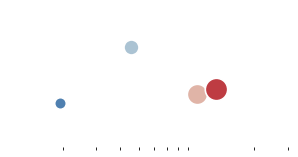

Saved figure: Fig4f_bubble_only.svg
Saved legend: Fig4f_bubble_size_legend.svg


In [17]:
# -*- coding: utf-8 -*-
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.patches import Circle
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# Fig.4f. Bubble-only visual SVG
# No text / no ticks / no axis / no legend / no line
# ============================================================

nature_rb_cmap = LinearSegmentedColormap.from_list(
    "nature_red_blue",
    [
        "#3B6EA8",
        "#7AA6C2",
        "#E8E8E8",
        "#D98B73",
        "#B2182B",
    ],
)

fig_w = 7.08 / 2.54
fig_h = 3.5 / 2.54

plot_df = summary_df.copy()

screening_fraction_pct = plot_df["screening_fraction"].values * 100
recall_pct = plot_df["future_positive_recall"].values * 100
recommended = plot_df["n_recommended"].values

fig, ax = plt.subplots(figsize=(fig_w, fig_h))

order = np.argsort(screening_fraction_pct)

sf = screening_fraction_pct[order]
recall = recall_pct[order]
rec_num = recommended[order]

# bubble size = searched molecular number
size_min = 70
size_max = 260
rec_norm = (rec_num - rec_num.min()) / (rec_num.max() - rec_num.min() + 1e-12)
point_sizes = size_min + rec_norm * (size_max - size_min)

# bubble colors from nature red-blue colormap
point_colors = nature_rb_cmap(np.linspace(0.08, 0.92, len(sf)))

for i in range(len(sf)):
    ax.scatter(
        sf[i],
        recall[i],
        s=point_sizes[i],
        color=point_colors[i],
        edgecolor="white",
        linewidth=1.2,
        zorder=3,
    )

ax.set_xscale("log")
ax.set_xlim(min(sf) * 0.55, max(sf) * 2.4)
ax.set_ylim(0, max(recall) * 1.38)

# remove all visual decorations
ax.set_xlabel("")
ax.set_ylabel("")
ax.set_xticks([])
ax.set_yticks([])
ax.tick_params(
    left=False,
    bottom=False,
    labelleft=False,
    labelbottom=False,
)

for spine in ax.spines.values():
    spine.set_visible(False)

ax.grid(False)
ax.set_facecolor("none")
fig.patch.set_alpha(0)

plt.subplots_adjust(left=0, right=1, top=1, bottom=0)

fig.savefig(
    "Fig4f_bubble_only.svg",
    format="svg",
    transparent=True,
    bbox_inches="tight",
    pad_inches=0,
)

plt.show()
plt.close(fig)


# ============================================================
# Bubble-size legend SVG
# ============================================================

def value_to_scatter_size(values, vmin, vmax, size_min=70, size_max=260):
    """
    将真实数值映射为 scatter 的 s 值
    """
    values = np.asarray(values, dtype=float)
    norm = (values - vmin) / (vmax - vmin + 1e-12)
    return size_min + norm * (size_max - size_min)


def save_bubble_size_legend_svg(
    out_path,
    legend_values,
    value_min,
    value_max,
    size_min=70,
    size_max=260,
    title="Recommended\nmolecules",
    number_fmt="{:.0f}",
):
    """
    单独生成 bubble size 图例
    风格：空心圆 + 引线 + 数值标签
    """
    # 先映射成 scatter size
    scatter_sizes = value_to_scatter_size(
        legend_values, value_min, value_max, size_min=size_min, size_max=size_max
    )

    # scatter 的 s 是面积，视觉半径与 sqrt(s) 成正比
    radii_raw = np.sqrt(scatter_sizes)

    # 归一化半径，方便在图例画布中排版
    r_min, r_max = radii_raw.min(), radii_raw.max()
    radii = 0.11 + (radii_raw - r_min) / (r_max - r_min + 1e-12) * (0.23 - 0.11)

    # 为了和示意图一致：大圆在上，小圆在下，基本共底/偏左重叠
    order = np.argsort(legend_values)[::-1]   # 从大到小
    legend_values = np.array(legend_values)[order]
    radii = np.array(radii)[order]

    fig, ax = plt.subplots(figsize=(2.0, 1.6))
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.set_aspect("equal")
    ax.axis("off")
    ax.set_facecolor("none")
    fig.patch.set_alpha(0)

    # 标题
    ax.text(
        0.08, 0.94, title,
        ha="left", va="top",
        fontsize=10, fontweight="bold"
    )

    # 圆心位置（共底重叠）
    base_y = 0.18
    cx = 0.38

    circles_info = []
    for i, (val, r) in enumerate(zip(legend_values, radii)):
        cy = base_y + r
        circles_info.append((val, cx, cy, r))

        circ = Circle(
            (cx, cy),
            r,
            facecolor="none",
            edgecolor="#4D4D4D",
            linewidth=1.2
        )
        ax.add_patch(circ)

    # 引线和标签
    line_x_end = 0.82
    text_x = 0.84

    for val, cx, cy, r in circles_info:
        # 从每个圆的右上边缘附近拉一条水平线
        y_line = cy + r * 0.18
        x_start = cx + r * 0.72

        ax.plot(
            [x_start, line_x_end],
            [y_line, y_line],
            color="#4D4D4D",
            linewidth=1.0
        )

        ax.text(
            text_x, y_line,
            number_fmt.format(val),
            ha="left", va="center",
            fontsize=9
        )

    plt.subplots_adjust(left=0, right=1, top=1, bottom=0)

    fig.savefig(
        out_path,
        format="svg",
        transparent=True,
        bbox_inches="tight",
        pad_inches=0
    )
    plt.close(fig)


# ============================================================
# 你可以自己指定图例显示哪几个数值
# ============================================================

# 方法1：自动取 min / median / max
legend_values = [
    int(rec_num.min()),
    int(np.median(rec_num)),
    int(rec_num.max()),
]

# 如果你想手动指定，就改成类似下面这样：
# legend_values = [500, 1500, 2500]

save_bubble_size_legend_svg(
    out_path="Fig4f_bubble_size_legend.svg",
    legend_values=legend_values,
    value_min=rec_num.min(),
    value_max=rec_num.max(),
    size_min=size_min,
    size_max=size_max,
    title="Population",   # 如果你想完全模仿示意图，就保留 Population
    # title="Recommended\nmolecules",  # 更符合你这张图含义
    number_fmt="{:.0f}",
)

print("Saved figure: Fig4f_bubble_only.svg")
print("Saved legend: Fig4f_bubble_size_legend.svg")